# Cell Embedding Model (4/2, Adding Grid Search Cross Validation)
This notebook:
- Builds graphs for each of the reigons within dataset using nearest neigbors, with each region constitution a connected component
- Trains a single GCN for the cell-type classification task on these graph
- Uses the soft logits from the final hidden layer (d=25 for the 25 cell types) as embeddings of every cell in the dataset
- Saves a file with all of the cell embeddings
- Trains a NN (Autoencoder) to reduce these embeddings to d=3 and then recover th
- Normalizes these outputs to RGB values and paints a PNG image for each region

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()
            total += data.y.size(0)
    return correct / total


In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.0 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.nn import SAGEConv, BatchNorm

class SAGEClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        self.lin0 = nn.Linear(in_channels, hidden_channels)
        self.bn0 = nn.BatchNorm1d(hidden_channels)

        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.bn1 = BatchNorm(hidden_channels)

        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm(hidden_channels)

        self.lin = nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.lin0(x)
        x = self.bn0(x)
        x = F.relu(x)

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.lin(x)
        return x

In [ ]:
from torch.nn import Parameter

class NormedLinear(nn.Module):

    def __init__(self, in_features, out_features):
        super(NormedLinear, self).__init__()
        self.weight = Parameter(torch.Tensor(in_features, out_features))
        self.weight.data.uniform_(-1, 1).renorm_(2, 1, 1e-5).mul_(1e5)

    def forward(self, x):
        out = F.normalize(x, dim=1).mm(F.normalize(self.weight, dim=0))
        return 10 * out

from torch_geometric.nn import SAGEConv, BatchNorm

class Stellar(nn.Module):
    def __init__(self, x_dim, num_cls):
        super(Stellar, self).__init__()
        self.x_dim = x_dim
        hid_dim = 764

        self.conv1 = nn.Linear(x_dim, hid_dim)
        self.bn1 = nn.BatchNorm1d(hid_dim)

        self.conv2 = SAGEConv(hid_dim, hid_dim)
        self.bn2 = BatchNorm(hid_dim)

        self.conv3 = SAGEConv(hid_dim, hid_dim)
        self.bn3 = BatchNorm(hid_dim)

        self.relu = nn.ReLU()
        self.linear = NormedLinear(hid_dim, num_cls)

    def forward(self, x, edge_index):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = self.relu(x)

        out = self.linear(x)
        return out

## Data Preparation
Below, we construct a class which represents each individual region and builds a graph using the nearest neighbors of each cell.
Afterwards, we use this class to create objects for each of the unique regions in our dataset.

In [ ]:
import pandas as pd
# Set pandas to show all columns for debugging
pd.set_option('display.max_columns', None)

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/1024x1024_dataset.csv', index_col=0)

# Parse columns
unique_region = df["unique_region"].values
labels = df["Cell Type"].values

# Cell positions
x_positions = df['x'].to_numpy()
y_positions = df['y'].to_numpy()
print(x_positions)

# Drop everything not used in GNN features
drop_cols = [
    "Cell Type", "unique_region", "donor", "array", "Xcorr", "Ycorr",
    "Tissue_location", "tissue", "region", "OLFM4", "FAP", "CD25",
    "CK7", "MUC6", "Cell Type em", "Cell subtype", "Neighborhood",
    "Neigh_sub", "Neighborhood_Ind", "NeighInd_sub", "Community",
    "Major Community", "Tissue Segment", "Tissue Unit", "CollIV"
]
features_df = df.drop(columns=drop_cols)
feature_cols = features_df.columns

/tmp/ipython-input-2153975300.py:6: DtypeWarning: Columns (73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/1024x1024_dataset.csv', index_col=0)


[434 565 661 ... 723 227 232]


In [ ]:
!pip install torch_geometric

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data, Dataset
import numpy as np

class RegionGraphDataset(Dataset):
    def __init__(self, df, feature_cols, label_col='Cell Type', region_col='unique_region', pos_cols=['x', 'y'], k_neighbors=30):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.region_col = region_col
        self.pos_cols = pos_cols
        self.k = k_neighbors

        self.label_encoder = LabelEncoder()
        self.df[label_col] = self.label_encoder.fit_transform(self.df[label_col])
        self.label_col = label_col

        self.region_ids = self.df[self.region_col].unique()

        self.data_list = []
        for region_id in self.region_ids:
            region_df = self.df[self.df[self.region_col] == region_id]

            features = region_df[self.feature_cols].values
            labels = region_df[self.label_col].values
            positions = region_df[self.pos_cols].values

            num_nodes = features.shape[0]

            if num_nodes == 1:
                edge_index = torch.empty((2, 0), dtype=torch.long)
            else:
                knn = NearestNeighbors(n_neighbors=min(self.k+1, num_nodes))
                knn.fit(positions)
                distances, indices = knn.kneighbors(positions)

                edge_list = []
                for i, neighbors in enumerate(indices):
                    for nbr in neighbors:
                        if i != nbr:
                            edge_list.append([i, nbr])

                edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

            x = torch.tensor(features, dtype=torch.float32)
            y = torch.tensor(labels, dtype=torch.long)
            data = Data(x=x, edge_index=edge_index, y=y)
            data.region_id = region_id
            self.data_list.append(data)

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]

    def decode_labels(self, y_pred):
        """
        y_pred: numpy array or tensor of predicted integer labels
        returns: list of original cell type strings
        """
        if isinstance(y_pred, torch.Tensor):
            y_pred = y_pred.cpu().numpy()
        return self.label_encoder.inverse_transform(y_pred)


In [ ]:
from torch_geometric.loader import DataLoader
import torch.optim as optim

feature_cols = feature_cols
dataset = RegionGraphDataset(
    df=df,
    feature_cols=feature_cols,
    k_neighbors=20
)

train_loader = DataLoader(dataset, batch_size=1, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
model = SAGEClassifier(
    in_channels=len(feature_cols),
    hidden_channels=512,
    num_classes=len(np.unique(df['Cell Type']))
).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
for epoch in range(1, 31):
    loss = train_one_epoch(model, train_loader, optimizer, device)
    acc = evaluate(model, train_loader, device)
    print(f"Epoch {epoch}, Loss {loss:.4f}, Train Acc {acc:.4f}")

Epoch 1, Loss 2.7859, Train Acc 0.1724
Epoch 2, Loss 2.6846, Train Acc 0.2175
Epoch 3, Loss 2.2079, Train Acc 0.3921
Epoch 4, Loss 1.5908, Train Acc 0.5718
Epoch 5, Loss 1.1799, Train Acc 0.6707
Epoch 6, Loss 0.9677, Train Acc 0.6970
Epoch 7, Loss 0.8292, Train Acc 0.6658
Epoch 8, Loss 0.7842, Train Acc 0.7417
Epoch 9, Loss 0.7061, Train Acc 0.7736
Epoch 10, Loss 0.6759, Train Acc 0.7837
Epoch 11, Loss 0.6358, Train Acc 0.6695
Epoch 12, Loss 0.6274, Train Acc 0.7474
Epoch 13, Loss 0.5893, Train Acc 0.7477
Epoch 14, Loss 0.5904, Train Acc 0.7727
Epoch 15, Loss 0.5650, Train Acc 0.7935
Epoch 16, Loss 0.5389, Train Acc 0.7968
Epoch 17, Loss 0.5274, Train Acc 0.8271
Epoch 18, Loss 0.5233, Train Acc 0.7455


KeyboardInterrupt: 

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-5)
for epoch in range(1, 31):
    loss = train_one_epoch(model, train_loader, optimizer, device)
    acc = evaluate(model, train_loader, device)
    print(f"Epoch {epoch}, Loss {loss:.4f}, Train Acc {acc:.4f}")

Epoch 1, Loss 0.4846, Train Acc 0.8450
Epoch 2, Loss 0.4638, Train Acc 0.8477
Epoch 3, Loss 0.4570, Train Acc 0.8495
Epoch 4, Loss 0.4525, Train Acc 0.8495


KeyboardInterrupt: 

In [ ]:
model = Stellar(
    len(feature_cols),
    len(np.unique(df['Cell Type']))
).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(1, 31):
    loss = train_one_epoch(model, train_loader, optimizer, device)
    acc = evaluate(model, train_loader, device)
    print(f"Epoch {epoch}, Loss {loss:.4f}, Train Acc {acc:.4f}")

Epoch 1, Loss 2.7817, Train Acc 0.1715
Epoch 2, Loss 2.6946, Train Acc 0.1696
Epoch 3, Loss 2.2310, Train Acc 0.3610
Epoch 4, Loss 1.6168, Train Acc 0.5027
Epoch 5, Loss 1.3606, Train Acc 0.5533
Epoch 6, Loss 1.1145, Train Acc 0.6451
Epoch 7, Loss 0.9532, Train Acc 0.6909
Epoch 8, Loss 0.8459, Train Acc 0.7110
Epoch 9, Loss 0.7873, Train Acc 0.6978
Epoch 10, Loss 0.7188, Train Acc 0.7520
Epoch 11, Loss 0.6982, Train Acc 0.7131
Epoch 12, Loss 0.6707, Train Acc 0.7875
Epoch 13, Loss 0.6163, Train Acc 0.7877
Epoch 14, Loss 0.6292, Train Acc 0.7863
Epoch 15, Loss 0.5917, Train Acc 0.7705
Epoch 16, Loss 0.5673, Train Acc 0.7633
Epoch 17, Loss 0.6076, Train Acc 0.7747
Epoch 18, Loss 0.5447, Train Acc 0.8044
Epoch 19, Loss 0.5349, Train Acc 0.8142
Epoch 20, Loss 0.5152, Train Acc 0.8264
Epoch 21, Loss 0.5043, Train Acc 0.8232
Epoch 22, Loss 0.5095, Train Acc 0.8050
Epoch 23, Loss 0.5124, Train Acc 0.8223
Epoch 24, Loss 0.4795, Train Acc 0.8398
Epoch 25, Loss 0.4794, Train Acc 0.8175
Epoch 26,

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-5)
for epoch in range(1, 31):
    loss = train_one_epoch(model, train_loader, optimizer, device)
    acc = evaluate(model, train_loader, device)
    print(f"Epoch {epoch}, Loss {loss:.4f}, Train Acc {acc:.4f}")

Epoch 1, Loss 0.4095, Train Acc 0.8611
Epoch 2, Loss 0.4080, Train Acc 0.8642
Epoch 3, Loss 0.4078, Train Acc 0.8641
Epoch 4, Loss 0.4074, Train Acc 0.8636
Epoch 5, Loss 0.4072, Train Acc 0.8647
Epoch 6, Loss 0.4069, Train Acc 0.8643
Epoch 7, Loss 0.4069, Train Acc 0.8619
Epoch 8, Loss 0.4066, Train Acc 0.8629
Epoch 9, Loss 0.4064, Train Acc 0.8651
Epoch 10, Loss 0.4061, Train Acc 0.8648
Epoch 11, Loss 0.4059, Train Acc 0.8637
Epoch 12, Loss 0.4057, Train Acc 0.8647
Epoch 13, Loss 0.4055, Train Acc 0.8646
Epoch 14, Loss 0.4054, Train Acc 0.8635
Epoch 15, Loss 0.4053, Train Acc 0.8612
Epoch 16, Loss 0.4049, Train Acc 0.8652
Epoch 17, Loss 0.4049, Train Acc 0.8641
Epoch 18, Loss 0.4047, Train Acc 0.8655
Epoch 19, Loss 0.4044, Train Acc 0.8641
Epoch 20, Loss 0.4042, Train Acc 0.8620
Epoch 21, Loss 0.4040, Train Acc 0.8635
Epoch 22, Loss 0.4038, Train Acc 0.8651
Epoch 23, Loss 0.4036, Train Acc 0.8651
Epoch 24, Loss 0.4034, Train Acc 0.8642
Epoch 25, Loss 0.4033, Train Acc 0.8645
Epoch 26,

In [ ]:
import pandas as pd
# Set pandas to show all columns for debugging
pd.set_option('display.max_columns', None)

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/1024x1024_dataset.csv', index_col=0)

# Parse columns
unique_region = df["unique_region"].values
labels = df["Cell Type"].values

# Cell positions
x_positions = df['x'].to_numpy()
y_positions = df['y'].to_numpy()
print(x_positions)

# Drop everything not used in GNN features
drop_cols = [
    "Cell Type", "unique_region", "donor", "array", "Xcorr", "Ycorr",
    "Tissue_location", "tissue", "region", "OLFM4", "FAP", "CD25",
    "CK7", "MUC6", "Cell Type em", "Cell subtype", "Neighborhood",
    "Neigh_sub", "Neighborhood_Ind", "NeighInd_sub", "Community",
    "Major Community", "Tissue Segment", "Tissue Unit", "CollIV"
]
keep_cols = ['CD34', 'CD38', 'Cytokeratin', 'CD19', 'CD4', 'CD49f', 'aSMA', 'CD161', 'CD163', 'NKG2D', 'CD16', 'CD49a', 'CD138',  'CD8', 'CD206',  'CD117', 'CD36', 'CD7', 'SOX9', 'CD68', 'CD57', 'Podoplanin', 'CD44', 'CD56', 'CD31', 'MUC1', 'aDef5', 'CD3', 'Synapto', 'ITLN1', 'Vimentin', 'CD15', 'CD11c', 'CD45', 'CD66', 'HLADR', 'Ki67', 'CD21',  'CD90', 'CHGA', 'CD123']
features_df = df[keep_cols]
feature_cols = features_df.columns
print(feature_cols)

/tmp/ipython-input-2181239504.py:6: DtypeWarning: Columns (73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/1024x1024_dataset.csv', index_col=0)


[434 565 661 ... 723 227 232]
Index(['CD34', 'CD38', 'Cytokeratin', 'CD19', 'CD4', 'CD49f', 'aSMA', 'CD161',
       'CD163', 'NKG2D', 'CD16', 'CD49a', 'CD138', 'CD8', 'CD206', 'CD117',
       'CD36', 'CD7', 'SOX9', 'CD68', 'CD57', 'Podoplanin', 'CD44', 'CD56',
       'CD31', 'MUC1', 'aDef5', 'CD3', 'Synapto', 'ITLN1', 'Vimentin', 'CD15',
       'CD11c', 'CD45', 'CD66', 'HLADR', 'Ki67', 'CD21', 'CD90', 'CHGA',
       'CD123'],
      dtype='object')


In [ ]:
df = df[['Cell Type','unique_region','x','y']]
df.shape

(2592311, 4)

In [ ]:
df.head()

,Cell Type,unique_region,x,y
MUC2,,,,
-0.303994,NK,B004_Ascending,434,382
-0.301927,NK,B004_Ascending,565,465
-0.302206,NK,B004_Ascending,661,355
-0.304219,NK,B004_Ascending,826,267
-0.294644,NK,B004_Ascending,739,439


In [ ]:
df1 = pd.read_csv("drive/MyDrive/cell_embeddings.csv")
df1.shape

(2592311, 28)

In [ ]:
df1.head()

,x,y,region,prob_class0,prob_class1,prob_class2,prob_class3,prob_class4,prob_class5,prob_class6,prob_class7,prob_class8,prob_class9,prob_class10,prob_class11,prob_class12,prob_class13,prob_class14,prob_class15,prob_class16,prob_class17,prob_class18,prob_class19,prob_class20,prob_class21,prob_class22,prob_class23,prob_class24
0,434,382,B004_Ascending,0.000168,0.000005,0.158509,7.306978e-08,0.000004,0.000012,4.156397e-06,8.774267e-07,5.475741e-07,0.000003,0.000268,0.000003,0.000003,5.224689e-07,0.000004,8.825942e-08,0.840157,0.000613,0.000118,0.000011,1.186485e-07,0.000048,0.000039,0.000009,0.000021
1,565,465,B004_Ascending,0.027036,0.036189,0.000456,4.775565e-01,0.018246,0.008158,4.710367e-07,6.263989e-04,5.756432e-03,0.024377,0.085176,0.005436,0.003355,6.941410e-05,0.009801,8.924435e-04,0.004983,0.133771,0.001888,0.003422,6.794071e-04,0.000515,0.050863,0.096157,0.004591
2,661,355,B004_Ascending,0.000258,0.000472,0.028910,9.215923e-06,0.000096,0.000827,2.182230e-04,2.261511e-06,1.500394e-06,0.000372,0.000697,0.478280,0.000077,1.538003e-05,0.000041,3.623293e-05,0.477269,0.002370,0.002763,0.000231,5.750678e-06,0.000992,0.005804,0.000193,0.000057
3,826,267,B004_Ascending,0.015109,0.005193,0.008532,8.633848e-05,0.001027,0.004175,5.199927e-05,1.294655e-05,7.622870e-05,0.000913,0.002006,0.387819,0.000142,1.160916e-04,0.000123,5.246982e-05,0.473917,0.001660,0.001053,0.000220,7.540340e-06,0.003047,0.065482,0.027111,0.002067
4,739,439,B004_Ascending,0.027876,0.059822,0.000107,2.242883e-01,0.015348,0.004501,2.172979e-07,1.852719e-04,9.821513e-03,0.008859,0.028969,0.011701,0.002509,9.284273e-05,0.006467,4.064996e-04,0.009830,0.184847,0.000790,0.001863,5.420372e-04,0.000319,0.201525,0.198495,0.000835


In [ ]:
df2 = df1
df1 = df

In [ ]:
df2 = df2.rename(columns={
    'region': 'unique_region',
})

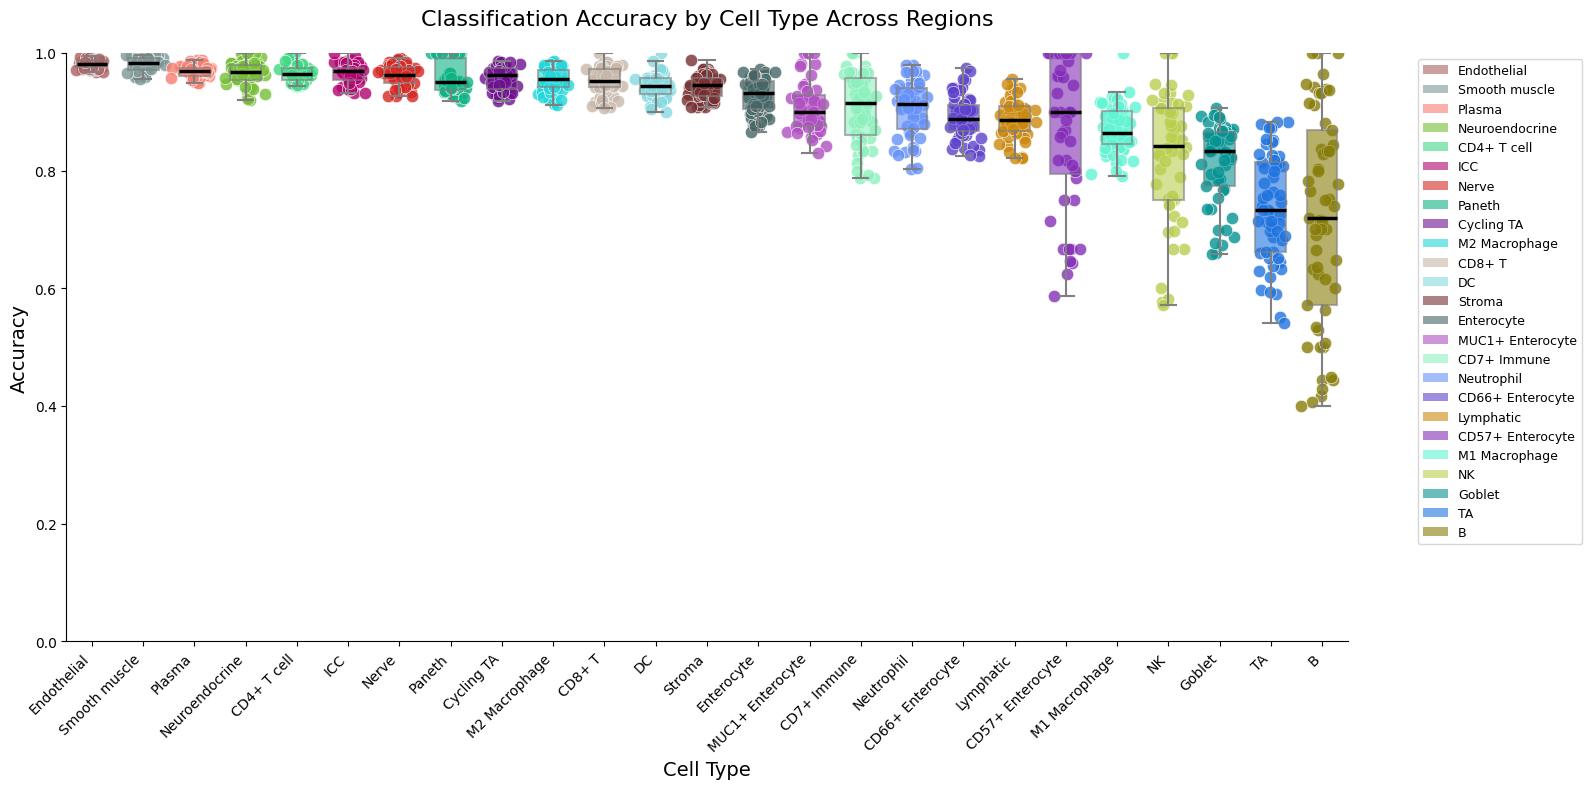

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 提供的类别名称和颜色
class_names = [
    "B", "CD4+ T cell", "CD57+ Enterocyte", "CD66+ Enterocyte", "CD7+ Immune",
    "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
    "Goblet", "ICC", "Lymphatic", "M1 Macrophage", "M2 Macrophage",
    "MUC1+ Enterocyte", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
    "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
]

# 颜色字典（RGB值转换为0-1范围）
color_dict = {
    1: [x/255 for x in [134.9, 124.1, 8.7]],
    2: [x/255 for x in [62.3, 216.0, 132.0]],
    3: [x/255 for x in [130.9, 46.4, 182.5]],
    4: [x/255 for x in [92.8, 63.6, 202.5]],
    5: [x/255 for x in [140.1, 239.7, 189.0]],
    6: [x/255 for x in [200.0, 183.1, 168.9]],
    7: [x/255 for x in [108.3, 16.1, 142.3]],
    8: [x/255 for x in [132.7, 217.1, 223.4]],
    9: [x/255 for x in [170.6, 96.0, 98.0]],
    10: [x/255 for x in [68.4, 101.1, 101.3]],
    11: [x/255 for x in [4.6, 146.9, 145.6]],
    12: [x/255 for x in [177.1, 1.5, 112.2]],
    13: [x/255 for x in [202.6, 136.4, 12.3]],
    14: [x/255 for x in [95.1, 244.3, 209.6]],
    15: [x/255 for x in [32.5, 214.2, 217.8]],
    16: [x/255 for x in [176.2, 78.6, 193.2]],
    17: [x/255 for x in [185.9, 206.0, 77.8]],
    18: [x/255 for x in [212.0, 39.3, 35.0]],
    19: [x/255 for x in [117.1, 190.4, 53.4]],
    20: [x/255 for x in [101.2, 145.2, 246.9]],
    21: [x/255 for x in [13.7, 179.1, 133.2]],
    22: [x/255 for x in [247.4, 125.5, 111.5]],
    23: [x/255 for x in [122.9, 151.0, 150.0]],
    24: [x/255 for x in [118.0, 45.6, 47.7]],
    25: [x/255 for x in [31.1, 114.7, 222.5]],
}

# 实际处理开始
# 1. 从df2中确定预测的Cell Type
prob_columns = [col for col in df2.columns if col.startswith('prob_class')]
df2['predicted_class'] = df2[prob_columns].idxmax(axis=1).str.extract('(\d+)').astype(int)
df2['predicted_CellType'] = df2['predicted_class'].apply(lambda x: class_names[x])

# 2. 合并两个DataFrame以比较真实和预测的Cell Type
merged_df = pd.merge(df1, df2, on=['unique_region', 'x', 'y'], how='inner')
merged_df['correct'] = merged_df['Cell Type'] == merged_df['predicted_CellType']

# 3. 计算每个区域每个Cell Type的分类准确率
accuracy_results = []

for region in merged_df['unique_region'].unique():
    for cell_type in merged_df['Cell Type'].unique():
        subset = merged_df[(merged_df['unique_region'] == region) &
                         (merged_df['Cell Type'] == cell_type)]
        if len(subset) > 0:
            accuracy = subset['correct'].mean()
            accuracy_results.append({
                'unique_region': region,
                'Cell Type': cell_type,
                'accuracy': accuracy
            })

accuracy_df = pd.DataFrame(accuracy_results)

celltype_stats = accuracy_df.groupby('Cell Type')['accuracy'].describe()

# 定义离群值阈值（这里使用Q1-1.5*IQR作为下限，只过滤过小的离群值）
def filter_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    Q2 = group.quantile(0.5)
    IQR = Q3 - Q1
    lower_bound = Q2 - 1 * IQR
    # 只保留不低于下限的值
    return group[group >= lower_bound]

# 应用过滤
filtered_accuracy = accuracy_df.groupby('Cell Type')['accuracy'].apply(filter_outliers).reset_index()
filtered_accuracy_df = accuracy_df.loc[filtered_accuracy['level_1']].copy()

# 使用过滤后的数据重新计算平均准确率和排序
mean_accuracy = filtered_accuracy_df.groupby('Cell Type')['accuracy'].mean().sort_values(ascending=False)
cell_type_order = mean_accuracy.index.tolist()

colors = [color_dict[i+1] for i, name in enumerate(class_names) if name in cell_type_order]
name_to_color_idx = {name: idx+1 for idx, name in enumerate(class_names)}

# 根据排序后的cell_type_order获取对应的颜色
colors = [color_dict[name_to_color_idx[cell_type]] for cell_type in cell_type_order]

# 6. 绘制箱线图和散点图（使用过滤后的数据）
plt.figure(figsize=(16, 8))
ax = plt.gca()

# 定义箱线图样式
boxprops = dict(linestyle='-', linewidth=1.5, color='gray')
whiskerprops = dict(linestyle='-', linewidth=1.5, color='gray')
capprops = dict(linestyle='-', linewidth=1.5, color='gray')
medianprops = dict(linestyle='-', linewidth=2.5, color='black')

# 绘制箱线图
boxplot = ax.boxplot([filtered_accuracy_df[filtered_accuracy_df['Cell Type'] == ct]['accuracy']
                     for ct in cell_type_order],
                     positions=range(len(cell_type_order)),
                     patch_artist=True,
                     widths=0.6,
                     boxprops=boxprops,
                     whiskerprops=whiskerprops,
                     capprops=capprops,
                     medianprops=medianprops,
                     showfliers=False)

# 为每个箱线图设置颜色（使用重新排序后的颜色）
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 绘制散点图（使用相同的颜色顺序）
for i, cell_type in enumerate(cell_type_order):
    subset = filtered_accuracy_df[filtered_accuracy_df['Cell Type'] == cell_type]
    plt.scatter(
        x=np.random.normal(i, 0.15, size=len(subset)),  # 添加一些抖动
        y=subset['accuracy'],
        color=colors[i],
        edgecolor='white',
        linewidth=0.5,
        s=80,
        alpha=0.8,
        label=cell_type
    )

# 设置图表属性
plt.title('Classification Accuracy by Cell Type Across Regions', fontsize=16, pad=20)
plt.xlabel('Cell Type', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(range(len(cell_type_order)), cell_type_order, rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1)

# 网格线和边框设置
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# 添加图例（使用重新排序后的颜色和类别）
handles = [plt.Rectangle((0,0),1,1, fc=colors[i], alpha=0.6) for i in range(len(cell_type_order))]
plt.legend(handles, cell_type_order, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

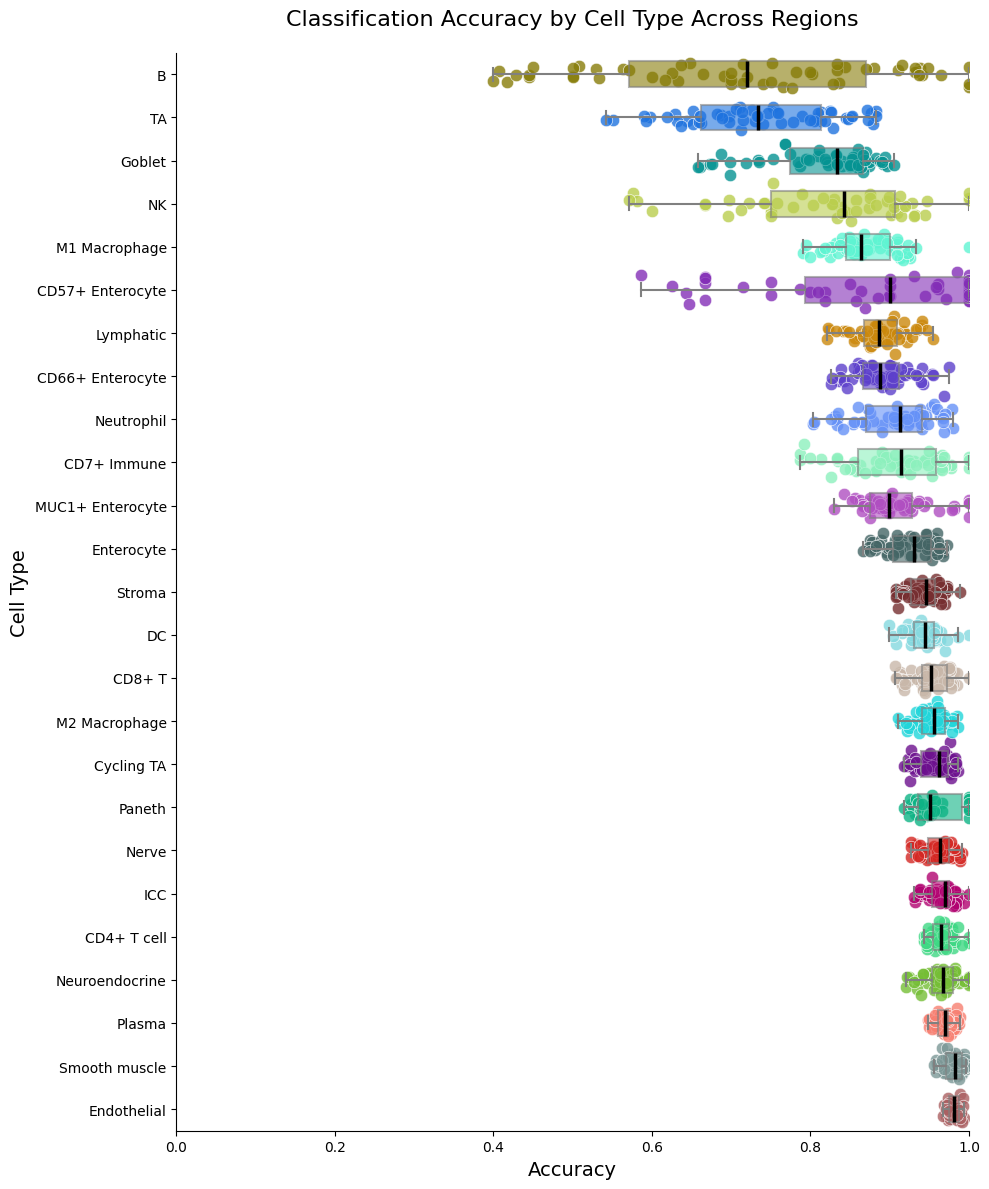

In [ ]:
plt.figure(figsize=(10, 12))  # 改成竖图
ax = plt.gca()

# 箱线图 (横向)
boxplot = ax.boxplot(
    [filtered_accuracy_df[filtered_accuracy_df['Cell Type'] == ct]['accuracy']
     for ct in cell_type_order],
    positions=range(len(cell_type_order)),
    patch_artist=True,
    widths=0.6,
    vert=False,   # 横向
    boxprops=boxprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    medianprops=medianprops,
    showfliers=False
)

# 给箱子上色
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 散点图 (横向)
for i, cell_type in enumerate(cell_type_order):
    subset = filtered_accuracy_df[filtered_accuracy_df['Cell Type'] == cell_type]
    plt.scatter(
        x=subset['accuracy'],   # 横坐标=accuracy
        y=np.random.normal(i, 0.15, size=len(subset)),  # 在纵坐标抖动
        color=colors[i],
        edgecolor='white',
        linewidth=0.5,
        s=80,
        alpha=0.8
    )

# 设置轴和标题
plt.title('Classification Accuracy by Cell Type Across Regions', fontsize=16, pad=20)
plt.xlabel('Accuracy', fontsize=14)
plt.ylabel('Cell Type', fontsize=14)
plt.yticks(range(len(cell_type_order)), cell_type_order, fontsize=10)
plt.xticks(fontsize=10)
plt.xlim(0, 1)

# 去掉多余边框
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
print(np.mean(mean_accuracy))

0.8622458395652882


In [ ]:
from torch.utils.data import Dataset

class CellFeatureDataset(Dataset):
    def __init__(self, df, feature_cols, label_col):
        """
        df: pandas DataFrame, each row is a cell
        feature_cols: list of biomarker feature column names
        label_col: cell type label (already encoded)
        """
        self.features = df[feature_cols].values  # shape [num_cells, num_features]
        self.labels = df[label_col].values        # shape [num_cells]

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        x = torch.tensor(self.features[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch

class MLPClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 1024)
        self.bn2 = nn.BatchNorm1d(1024)

        self.fc3 = nn.Linear(1024, 256)
        self.bn3 = nn.BatchNorm1d(256)


        self.fc4 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)
        return x


In [ ]:
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# --------- Prepare data ----------
# Encode labels
label_encoder = LabelEncoder()
df['Cell Type'] = label_encoder.fit_transform(df['Cell Type'])

# Split train/test
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Cell Type"]
)

# Create datasets
train_dataset = CellFeatureDataset(train_df, feature_cols, label_col="Cell Type")
test_dataset = CellFeatureDataset(test_df, feature_cols, label_col="Cell Type")

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --------- Define model ----------
model = MLPClassifier(
    in_dim=len(feature_cols),
    hidden_dim=256,
    num_classes=len(np.unique(df['Cell Type']))
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# --------- Training ----------
for epoch in range(1, 11):
    model.train()
    total_loss = 0
    correct = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(dim=1)
        correct += (preds == y_batch).sum().item()

    acc = correct / len(train_dataset)
    print(f"Epoch {epoch}, Loss {loss/len(train_dataset):.4f}, Train Acc {acc:.4f}")

# --------- Evaluate on Test Set ----------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        outputs = model(x_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

# Compute accuracy
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.4f}")
'''
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

# Optional: Classification report
report = classification_report(all_labels, all_preds, target_names=label_encoder.classes_)
print(report)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
'''


Epoch 1, Loss 0.0000, Train Acc 0.8920
Epoch 2, Loss 0.0000, Train Acc 0.9081
Epoch 3, Loss 0.0000, Train Acc 0.9132
Epoch 4, Loss 0.0000, Train Acc 0.9160
Epoch 5, Loss 0.0000, Train Acc 0.9184


KeyboardInterrupt: 

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(1, 11):
    model.train()
    total_loss = 0
    correct = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(dim=1)
        correct += (preds == y_batch).sum().item()

    acc = correct / len(train_dataset)
    print(f"Epoch {epoch}, Loss {total_loss:.4f}, Train Acc {acc:.4f}")

Epoch 1, Loss 729.1139, Train Acc 0.9329
Epoch 2, Loss 726.6272, Train Acc 0.9332
Epoch 3, Loss 724.5843, Train Acc 0.9334
Epoch 4, Loss 723.1522, Train Acc 0.9335
Epoch 5, Loss 721.3781, Train Acc 0.9337
Epoch 6, Loss 719.3236, Train Acc 0.9338
Epoch 7, Loss 717.9218, Train Acc 0.9340
Epoch 8, Loss 716.9210, Train Acc 0.9340
Epoch 9, Loss 714.0992, Train Acc 0.9343


KeyboardInterrupt: 

In [ ]:
import torch
from torch.utils.data import DataLoader
import torch.optim as optim

# feature columns: all biomarkers, label列: cell type
#feature_cols = feature_col
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Cell Type'] = label_encoder.fit_transform(df['Cell Type'])

dataset = CellFeatureDataset(df, feature_cols, label_col="Cell Type")

train_loader = DataLoader(dataset, batch_size=512, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MLPClassifier(
    in_dim=len(feature_cols),
    hidden_dim=256,
    num_classes=len(np.unique(df['Cell Type']))
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(1, 20):
    model.train()
    total_loss = 0
    correct = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(dim=1)
        correct += (preds == y_batch).sum().item()

    acc = correct / len(dataset)
    print(f"Epoch {epoch}, Loss {total_loss:.4f}, Train Acc {acc:.4f}")


Epoch 1, Loss 3473.1247, Train Acc 0.7910
Epoch 2, Loss 2001.8313, Train Acc 0.8617
Epoch 3, Loss 1803.7170, Train Acc 0.8741
Epoch 4, Loss 1686.1947, Train Acc 0.8814
Epoch 5, Loss 1603.6750, Train Acc 0.8866
Epoch 6, Loss 1540.0863, Train Acc 0.8908
Epoch 7, Loss 1490.1464, Train Acc 0.8940
Epoch 8, Loss 1451.8297, Train Acc 0.8964
Epoch 9, Loss 1418.2002, Train Acc 0.8986
Epoch 10, Loss 1386.3353, Train Acc 0.9008
Epoch 11, Loss 1360.7630, Train Acc 0.9023
Epoch 12, Loss 1336.4177, Train Acc 0.9040
Epoch 13, Loss 1317.5508, Train Acc 0.9052
Epoch 14, Loss 1297.1704, Train Acc 0.9067
Epoch 15, Loss 1278.8378, Train Acc 0.9078
Epoch 16, Loss 1262.0275, Train Acc 0.9089
Epoch 17, Loss 1247.7059, Train Acc 0.9100
Epoch 18, Loss 1233.5065, Train Acc 0.9109
Epoch 19, Loss 1219.7507, Train Acc 0.9117


In [ ]:
dataset = CellFeatureDataset(df, feature_cols=feature_cols, label_col='Cell Type')
dataloader = DataLoader(dataset, batch_size=128, shuffle=False)
model.eval()
all_probs = []

with torch.no_grad():
    for x_batch, _ in dataloader:
        x_batch = x_batch.to(device)
        output = model(x_batch)
        probs = torch.softmax(output, dim=1)
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)  # [num_cells, num_classes]

probs_np = all_probs.numpy()



In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Step 1 - predicted labels
pred_labels = probs_np.argmax(axis=1)  # [num_cells]

# Step 2 - true labels
# 如果 Cell Type 是字符串，需要 LabelEncoder
le = LabelEncoder()
true_labels_encoded = le.fit_transform(df['Cell Type'])

# Step 3 - confusion matrix
cm = confusion_matrix(true_labels_encoded, pred_labels)

# 可选：打印 class names
print("Classes:", le.classes_)
print("Confusion Matrix:\n", cm)

In [ ]:
result_df = pd.DataFrame(probs_np, columns=[f'prob_class{i}' for i in range(probs_np.shape[1])])
result_df['x'] = df['x'].values
result_df['y'] = df['y'].values
result_df['region'] = df['unique_region'].values

result_df = result_df[['x', 'y', 'region'] + [f'prob_class{i}' for i in range(probs_np.shape[1])]]
result_df.head()


,x,y,region,prob_class0,prob_class1,prob_class2,prob_class3,prob_class4,prob_class5,prob_class6,prob_class7,prob_class8,prob_class9,prob_class10,prob_class11,prob_class12,prob_class13,prob_class14,prob_class15,prob_class16,prob_class17,prob_class18,prob_class19,prob_class20,prob_class21,prob_class22,prob_class23,prob_class24
0,434,382,B004_Ascending,0.000168,0.000005,0.158509,7.306978e-08,0.000004,0.000012,4.156397e-06,8.774267e-07,5.475741e-07,0.000003,0.000268,0.000003,0.000003,5.224690e-07,0.000004,8.825942e-08,0.840157,0.000613,0.000118,0.000011,1.186485e-07,0.000048,0.000039,0.000009,0.000021
1,565,465,B004_Ascending,0.027036,0.036189,0.000456,4.775565e-01,0.018246,0.008158,4.710367e-07,6.263989e-04,5.756432e-03,0.024377,0.085176,0.005436,0.003355,6.941411e-05,0.009801,8.924435e-04,0.004983,0.133771,0.001888,0.003422,6.794071e-04,0.000515,0.050863,0.096157,0.004591
2,661,355,B004_Ascending,0.000258,0.000472,0.028910,9.215923e-06,0.000096,0.000827,2.182231e-04,2.261511e-06,1.500394e-06,0.000372,0.000697,0.478280,0.000077,1.538003e-05,0.000041,3.623293e-05,0.477269,0.002370,0.002763,0.000231,5.750678e-06,0.000992,0.005804,0.000193,0.000057
3,826,267,B004_Ascending,0.015109,0.005193,0.008532,8.633848e-05,0.001027,0.004175,5.199927e-05,1.294656e-05,7.622869e-05,0.000913,0.002006,0.387819,0.000142,1.160916e-04,0.000123,5.246982e-05,0.473917,0.001660,0.001053,0.000220,7.540340e-06,0.003047,0.065482,0.027111,0.002067
4,739,439,B004_Ascending,0.027876,0.059822,0.000107,2.242883e-01,0.015348,0.004501,2.172979e-07,1.852719e-04,9.821513e-03,0.008859,0.028969,0.011701,0.002509,9.284273e-05,0.006467,4.064996e-04,0.009830,0.184847,0.000790,0.001863,5.420372e-04,0.000319,0.201525,0.198495,0.000835


In [ ]:
result_df.to_csv("drive/MyDrive/cell_embeddings.csv", index=False)

## Dimensional Recution Network with Grid Search CV
We want to map the GCN's embeddings down to 3 dimensions for RGB-like representation, so our bottleneck dimension is 3. We accomplish this via an Autoencoder trained on MSE reconstruction.

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
result_df = pd.read_csv("drive/MyDrive/cell_embeddings_new.csv")
#result_df.head()

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, in_dim=25, bottleneck_dim=3, hidden_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Linear(int(hidden_dim/2), int(hidden_dim)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim)),
            nn.Linear(hidden_dim, int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Linear(int(hidden_dim/4), bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Linear(int(hidden_dim/2), hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim)),
            nn.Linear(hidden_dim, int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Linear(int(hidden_dim/4), in_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)


In [ ]:
# Dataset of all emebddings
emb_matrix = result_df[[col for col in result_df.columns if col.startswith("prob_")]].values # shape = [N, hidden_dim], N = total nodes from all graphs
emb_matrix_tensor = torch.tensor(emb_matrix, dtype=torch.float32)
emb_matrix_tensor

tensor([[4.7057e-07, 9.7333e-05, 1.1053e-01,  ..., 4.1122e-05, 8.2143e-06,
         6.6493e-08],
        [1.7376e-02, 5.6906e-03, 5.2517e-06,  ..., 4.0252e-02, 4.2315e-02,
         4.4513e-02],
        [2.5381e-04, 8.5959e-04, 4.2860e-02,  ..., 2.7291e-03, 1.6568e-04,
         5.7160e-04],
        ...,
        [7.7708e-07, 1.3178e-05, 6.2827e-08,  ..., 5.0651e-06, 2.9859e-05,
         9.0867e-03],
        [2.0009e-07, 2.2548e-06, 5.6568e-08,  ..., 4.4044e-07, 4.2465e-06,
         5.0561e-04],
        [8.7426e-11, 1.9282e-09, 3.1377e-13,  ..., 1.9383e-13, 6.9193e-11,
         1.0390e-06]])

In [ ]:
print(emb_matrix_tensor.min(), emb_matrix_tensor.max())
print(emb_matrix_tensor.sum(dim=1).mean())


tensor(0.) tensor(1.)
tensor(1.)


In [ ]:
def loss_function(x, out, z, alpha=0.001):
    recon_loss = F.mse_loss(out, x)
    batch_size = z.size(0)
    z_norm = F.normalize(z, dim=1)
    similarity_matrix = torch.matmul(z_norm, z_norm.T)

    diversity_loss = (similarity_matrix.sum() - torch.trace(similarity_matrix)) / (batch_size * (batch_size - 1))

    total_loss = recon_loss + alpha * diversity_loss
    return total_loss, recon_loss.item(), diversity_loss.item()


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(emb_matrix_tensor)

batch_size = 4096

train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Autoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
alpha = 0.005

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_recon = 0
    total_div = 0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()
        z, out = model(x)
        loss, recon_loss, diversity_loss = loss_function(x, out, z, alpha=alpha)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss
        total_div += diversity_loss

    print(f"Epoch {epoch+1}/{num_epochs} | Total Loss: {total_loss:.4f} | Recon: {total_recon:.4f} | Diversity: {total_div:.4f}")


KeyboardInterrupt: 

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-6)

num_epochs = 50
alpha = 0.005

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_recon = 0
    total_div = 0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()
        z, out = model(x)
        loss, recon_loss, diversity_loss = loss_function(x, out, z, alpha=alpha)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss
        total_div += diversity_loss

    print(f"Epoch {epoch+1}/{num_epochs} | Total Loss: {total_loss:.4f} | Recon: {total_recon:.4f} | Diversity: {total_div:.4f}")

Epoch 1/50 | Total Loss: 0.0585 | Recon: 0.0585 | Diversity: -0.0014
Epoch 2/50 | Total Loss: 0.0585 | Recon: 0.0585 | Diversity: 0.0121
Epoch 3/50 | Total Loss: 0.0585 | Recon: 0.0584 | Diversity: 0.0132
Epoch 4/50 | Total Loss: 0.0585 | Recon: 0.0584 | Diversity: 0.0126
Epoch 5/50 | Total Loss: 0.0584 | Recon: 0.0584 | Diversity: -0.0147
Epoch 6/50 | Total Loss: 0.0584 | Recon: 0.0584 | Diversity: 0.0022
Epoch 7/50 | Total Loss: 0.0584 | Recon: 0.0584 | Diversity: -0.0011
Epoch 8/50 | Total Loss: 0.0583 | Recon: 0.0583 | Diversity: 0.0004
Epoch 9/50 | Total Loss: 0.0582 | Recon: 0.0582 | Diversity: 0.0044
Epoch 10/50 | Total Loss: 0.0582 | Recon: 0.0582 | Diversity: 0.0031
Epoch 11/50 | Total Loss: 0.0582 | Recon: 0.0582 | Diversity: 0.0016
Epoch 12/50 | Total Loss: 0.0582 | Recon: 0.0582 | Diversity: -0.0020
Epoch 13/50 | Total Loss: 0.0581 | Recon: 0.0581 | Diversity: 0.0025
Epoch 14/50 | Total Loss: 0.0581 | Recon: 0.0581 | Diversity: 0.0040


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'drive/MyDrive/autoencoder_weights.pth')

In [ ]:
model = Autoencoder()
model.load_state_dict(torch.load('drive/MyDrive/autoencoder_weights.pth'))

<All keys matched successfully>

## Normalize Outputs to RBG and Save as CSV

In [ ]:
model.eval()
with torch.no_grad():
    x_in = torch.tensor(emb_matrix, dtype=torch.float32).to("cuda")
    model = model.to("cuda")
    z_3d = model.encoder(x_in).cpu().numpy()  # shape [N, 3]

# z_3d can have arbitrary range; let's min-max scale each dimension
min_vals = z_3d.min(axis=0)
max_vals = z_3d.max(axis=0)
print(min_vals, max_vals)

# Avoid zero-division if max == min
range_vals = (max_vals - min_vals)
range_vals[range_vals == 0] = 1e-9

scaled_3d = (z_3d - min_vals) / range_vals  # [0, 1]
rgb_3d = (scaled_3d * 255).astype(np.uint8) # [0..255]

# Add columns back to df
result_df["R"] = rgb_3d[:, 0]
result_df["G"] = rgb_3d[:, 1]
result_df["B"] = rgb_3d[:, 2]

# Save to csv
#result_df.to_csv("drive/MyDrive/node_embeddings_3d.csv", index=False)


[-6.290313  -6.6032205 -7.1406803] [7.1585207 6.791606  6.5948086]


In [ ]:
# To get these constants for image_decoder.ipynb
result_df.head()

,x,y,region,prob_class0,prob_class1,prob_class2,prob_class3,prob_class4,prob_class5,prob_class6,...,prob_class18,prob_class19,prob_class20,prob_class21,prob_class22,prob_class23,prob_class24,R,G,B
0,434,382,B004_Ascending,4.705660e-07,0.000097,0.110533,7.100830e-07,0.000597,0.000697,3.879244e-09,...,1.093408e-07,8.731959e-06,1.390562e-09,0.000036,0.000041,0.000008,6.649306e-08,99,68,103
1,565,465,B004_Ascending,1.737609e-02,0.005691,0.000005,4.632387e-01,0.044751,0.001160,3.635632e-06,...,7.166561e-05,2.087034e-05,4.273615e-04,0.001234,0.040252,0.042315,4.451319e-02,85,106,150
2,661,355,B004_Ascending,2.538061e-04,0.000860,0.042860,1.032352e-04,0.000172,0.002497,5.601124e-06,...,1.968857e-04,2.870663e-07,1.526547e-08,0.000363,0.002729,0.000166,5.715978e-04,99,67,104
3,826,267,B004_Ascending,6.305159e-03,0.027712,0.053753,5.908728e-03,0.004094,0.026612,1.535558e-04,...,8.124516e-05,1.174358e-05,2.077845e-07,0.003653,0.063591,0.001990,6.277059e-03,100,68,104
4,739,439,B004_Ascending,9.445610e-02,0.027518,0.000028,5.754628e-02,0.022052,0.001547,2.040477e-06,...,5.096602e-05,4.835770e-06,1.190377e-04,0.001823,0.387126,0.066070,6.473182e-03,150,20,162


## Save individual images as PNG

In [ ]:
import cv2  # or PIL
import os

save_dir = "drive/MyDrive/region_images"
os.makedirs(save_dir, exist_ok=True)

all_regions = result_df["region"].unique()
cnt = 0
for reg in all_regions:
    subset = result_df[result_df["region"] == reg]
    xs = subset["x"].values
    ys = subset["y"].values
    Rs = subset["R"].values
    Gs = subset["G"].values
    Bs = subset["B"].values

    # Create a blank image (adjust size if needed)
    # Example: 1024 x 1024, 3 channels
    img = np.ones((1024, 1024, 3), dtype=np.uint8) * 255

    for i in range(len(subset)):
        x_int = int(round(xs[i]))
        y_int = int(round(ys[i]))
        # Safety check
        if 0 <= x_int < 1024 and 0 <= y_int < 1024:
            img[y_int, x_int, 0] = Bs[i]  # OpenCV uses BGR order by default
            img[y_int, x_int, 1] = Gs[i]
            img[y_int, x_int, 2] = Rs[i]

    # Save the image
    save_path = os.path.join(save_dir, f"region_{cnt}.png")
    cv2.imwrite(save_path, img)
    cnt += 1

    print(f"Saved image for region {cnt} -> {save_path}")


Saved image for region 1 -> drive/MyDrive/region_images/region_0.png
Saved image for region 2 -> drive/MyDrive/region_images/region_1.png
Saved image for region 3 -> drive/MyDrive/region_images/region_2.png
Saved image for region 4 -> drive/MyDrive/region_images/region_3.png
Saved image for region 5 -> drive/MyDrive/region_images/region_4.png
Saved image for region 6 -> drive/MyDrive/region_images/region_5.png
Saved image for region 7 -> drive/MyDrive/region_images/region_6.png
Saved image for region 8 -> drive/MyDrive/region_images/region_7.png
Saved image for region 9 -> drive/MyDrive/region_images/region_8.png
Saved image for region 10 -> drive/MyDrive/region_images/region_9.png
Saved image for region 11 -> drive/MyDrive/region_images/region_10.png
Saved image for region 12 -> drive/MyDrive/region_images/region_11.png
Saved image for region 13 -> drive/MyDrive/region_images/region_12.png
Saved image for region 14 -> drive/MyDrive/region_images/region_13.png
Saved image for region 15

In [ ]:
# Save Models
import torch

# Save the classification model's parameters
torch.save(model.state_dict(), "gnn_model.pth")

# Save the autoencoder's parameters
torch.save(autoenc.state_dict(), "autoencoder.pth")

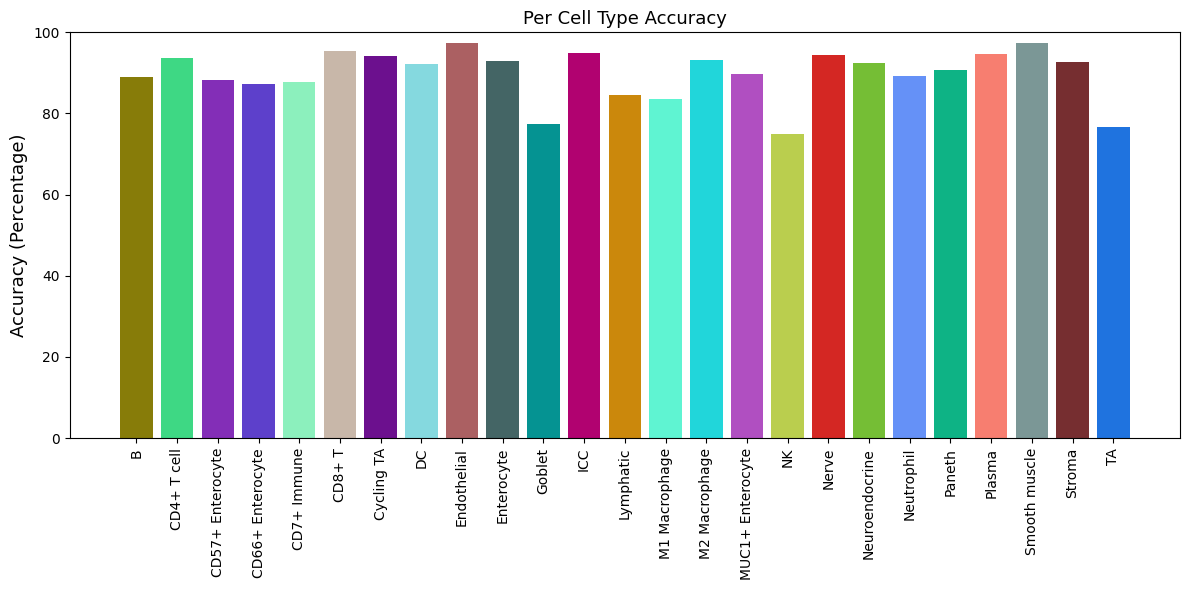

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- confusion matrix ----
confusion_matrix = np.array([
    [ 6236,   174,     0,     1,     4,    50,     3,    60,    16,    17,     0,    12,    16,     7,    33,     0,     7,    15,     2,     0,     0,   252,    31,    72,     2],
    [  246, 22445,     0,    15,     9,   421,     2,    32,    65,    75,     6,    15,    24,    23,    91,     1,    17,    68,     3,     1,     3,   151,    84,   124,    11],
    [    1,     1,   339,     0,     0,     0,     2,     1,     0,    12,     0,     0,     0,     0,     0,     3,    14,     2,     7,     0,     1,     0,     1,     0,     0],
    [    2,     4,     2,  8787,     1,    23,    24,     8,     4,   658,   223,     2,     3,     0,     6,    53,    13,     7,     3,    50,     0,     0,     8,    27,   162],
    [    2,     6,     1,     4,  1337,   103,     6,     0,     0,    38,     5,     0,     0,     0,     0,     1,     2,     6,     0,     1,     0,     2,     5,     4,     1],
    [   79,   505,     0,    31,    76, 40733,     9,    69,    30,   650,    77,    11,    18,    21,    55,     6,    33,    10,    24,    20,     8,    53,    43,   107,    21],
    [    7,     2,     0,    15,     3,    30, 15632,     4,    14,   279,   378,     2,     5,     3,     8,    41,     1,     0,     8,     0,     8,     3,    10,    10,   154],
    [   29,    64,     0,     5,     4,    65,     7,  5986,    11,    24,     3,     5,    47,    50,    68,     0,     1,     5,     0,    19,     0,    67,     1,    24,     1],
    [    9,    41,     1,    12,     3,    42,     4,    20, 36406,    90,     5,     9,   126,    15,    29,     2,     1,    19,     0,    85,     0,    46,   260,   127,    13],
    [    9,    54,    14,   346,     7,   482,   220,    21,    49, 94862,  3400,    45,   135,    31,    26,    34,    27,    42,    92,   106,   127,    58,   169,   624,  1062],
    [    2,     6,     3,   262,    10,   183,   465,     9,    11,  5063, 25646,    25,    17,     6,     4,   290,     1,    20,    44,     5,    64,    13,    34,    95,   822],
    [    4,    15,     0,     2,     1,    30,     2,    11,    12,    32,     6,  6599,    12,     1,    27,     1,     2,    46,     1,     2,     5,    23,    32,    72,    17],
    [    9,    25,     0,     3,     4,    54,     7,   110,   141,   214,     7,    19, 11091,    81,   141,     1,     5,   220,     1,    14,    16,    40,   438,   457,     8],
    [    8,    14,     0,     0,     1,    10,     0,    52,    16,    49,     1,     1,    43,  3767,   466,     0,     0,     3,     0,     2,     0,    23,    15,    29,     1],
    [   32,   173,     1,     8,     1,    62,     8,    92,    35,    96,     4,    17,   105,   388, 21416,     1,     1,    26,     2,    27,     5,   161,    74,   237,    12],
    [    0,     1,     6,    12,     0,     4,    25,     0,     0,   128,   117,     0,     0,     0,     5,  3243,     0,     1,     0,     1,     6,     2,     2,     6,    54],
    [    7,    15,    70,    25,     6,    53,     4,     0,     2,    27,     3,     2,     3,     1,     2,     1,   822,     5,     9,     2,     1,     3,     8,    25,     0],
    [    9,    46,     1,     1,     1,    13,     3,     6,    14,    59,    19,    27,   211,     0,    23,     1,     7, 14854,     2,     2,     7,    47,   189,   208,     3],
    [    1,     0,    11,     2,     0,     7,    15,     0,     2,   122,    45,     0,     3,     0,     2,     0,     0,     3,  2855,     1,     3,     2,     2,     8,     6],
    [    0,     3,     3,    19,     1,    10,     0,     3,    72,   131,     3,     3,     8,     0,    17,     1,     0,     1,     0,  2662,     0,    15,    16,    13,     0],
    [    0,    10,     2,     3,     1,    14,    10,     0,     0,   201,    90,     5,     9,     2,     3,    27,     0,     5,     7,     0,  4086,     2,     9,     8,     9],
    [  131,   226,     0,     4,     7,   125,     2,    61,    78,    68,     1,    77,    32,    28,   134,     1,     5,    70,     1,     7,     0, 25055,   116,   221,     5],
    [   23,    83,     0,    21,     3,    44,    19,     1,   140,   205,    18,    47,   230,     3,    20,     5,    11,   152,     1,    14,     6,   171, 74651,   759,    32],
    [   40,    79,     1,    26,     2,    78,    24,    23,   197,   826,    40,   117,   374,    24,   153,     0,    27,   244,     2,    21,    10,   228,   680, 40803,    43],
    [    1,     0,     0,    90,     1,    12,    61,     0,     3,  1575,   829,     7,     1,     0,     4,    10,     0,     2,    10,     2,    16,     3,    17,    49,  8793],
])

# ---- 类别名字 ----
class_names = [
    "B", "CD4+ T cell", "CD57+ Enterocyte", "CD66+ Enterocyte", "CD7+ Immune",
    "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
    "Goblet", "ICC", "Lymphatic", "M1 Macrophage", "M2 Macrophage",
    "MUC1+ Enterocyte", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
    "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
]

# ---- 计算逐 cell type accuracy ----
accuracies = []
for i in range(len(class_names)):
    correct = confusion_matrix[i, i]
    total = confusion_matrix[i, :].sum()
    acc = correct / total if total > 0 else 0
    accuracies.append(acc * 100)

# ---- 颜色表（转为 0-1） ----
color_dict = {
    1: [134.9, 124.1, 8.7],
    2: [62.3, 216.0, 132.0],
    3: [130.9, 46.4, 182.5],
    4: [92.8, 63.6, 202.5],
    5: [140.1, 239.7, 189.0],
    6: [200.0, 183.1, 168.9],
    7: [108.3, 16.1, 142.3],
    8: [132.7, 217.1, 223.4],
    9: [170.6, 96.0, 98.0],
    10: [68.4, 101.1, 101.3],
    11: [4.6, 146.9, 145.6],
    12: [177.1, 1.5, 112.2],
    13: [202.6, 136.4, 12.3],
    14: [95.1, 244.3, 209.6],
    15: [32.5, 214.2, 217.8],
    16: [176.2, 78.6, 193.2],
    17: [185.9, 206.0, 77.8],
    18: [212.0, 39.3, 35.0],
    19: [117.1, 190.4, 53.4],
    20: [101.2, 145.2, 246.9],
    21: [13.7, 179.1, 133.2],
    22: [247.4, 125.5, 111.5],
    23: [122.9, 151.0, 150.0],
    24: [118.0, 45.6, 47.7],
    25: [31.1, 114.7, 222.5],
}

# 转成 0-1 RGB 并排好顺序
colors = np.array([color_dict[i+1] for i in range(len(class_names))]) / 255.0

# ---- plot vertical bar chart ----
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(class_names))
ax.bar(x_pos, accuracies, color=colors)

ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=10, rotation=90)
ax.set_ylabel("Accuracy (Percentage)", fontsize=13)
ax.set_ylim(0, 100)
ax.set_title("Per Cell Type Accuracy", fontsize=13)

plt.tight_layout()
plt.savefig("cell_type_accuracy.png")
plt.show()

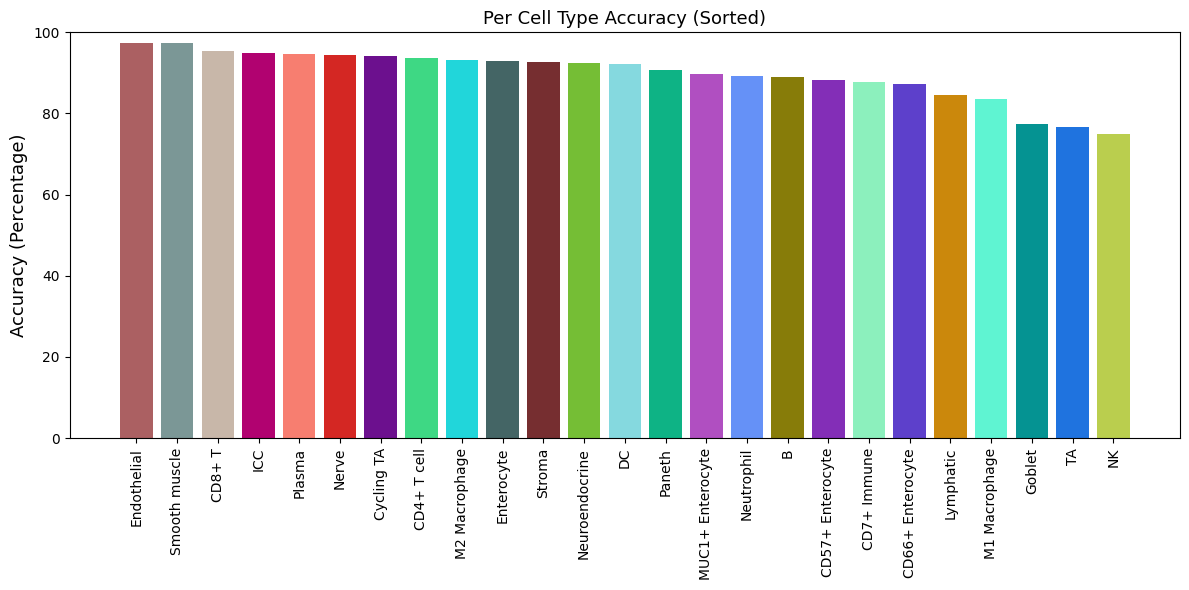

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- confusion matrix ----
confusion_matrix = np.array([
    [ 6236,   174,     0,     1,     4,    50,     3,    60,    16,    17,     0,    12,    16,     7,    33,     0,     7,    15,     2,     0,     0,   252,    31,    72,     2],
    [  246, 22445,     0,    15,     9,   421,     2,    32,    65,    75,     6,    15,    24,    23,    91,     1,    17,    68,     3,     1,     3,   151,    84,   124,    11],
    [    1,     1,   339,     0,     0,     0,     2,     1,     0,    12,     0,     0,     0,     0,     0,     3,    14,     2,     7,     0,     1,     0,     1,     0,     0],
    [    2,     4,     2,  8787,     1,    23,    24,     8,     4,   658,   223,     2,     3,     0,     6,    53,    13,     7,     3,    50,     0,     0,     8,    27,   162],
    [    2,     6,     1,     4,  1337,   103,     6,     0,     0,    38,     5,     0,     0,     0,     0,     1,     2,     6,     0,     1,     0,     2,     5,     4,     1],
    [   79,   505,     0,    31,    76, 40733,     9,    69,    30,   650,    77,    11,    18,    21,    55,     6,    33,    10,    24,    20,     8,    53,    43,   107,    21],
    [    7,     2,     0,    15,     3,    30, 15632,     4,    14,   279,   378,     2,     5,     3,     8,    41,     1,     0,     8,     0,     8,     3,    10,    10,   154],
    [   29,    64,     0,     5,     4,    65,     7,  5986,    11,    24,     3,     5,    47,    50,    68,     0,     1,     5,     0,    19,     0,    67,     1,    24,     1],
    [    9,    41,     1,    12,     3,    42,     4,    20, 36406,    90,     5,     9,   126,    15,    29,     2,     1,    19,     0,    85,     0,    46,   260,   127,    13],
    [    9,    54,    14,   346,     7,   482,   220,    21,    49, 94862,  3400,    45,   135,    31,    26,    34,    27,    42,    92,   106,   127,    58,   169,   624,  1062],
    [    2,     6,     3,   262,    10,   183,   465,     9,    11,  5063, 25646,    25,    17,     6,     4,   290,     1,    20,    44,     5,    64,    13,    34,    95,   822],
    [    4,    15,     0,     2,     1,    30,     2,    11,    12,    32,     6,  6599,    12,     1,    27,     1,     2,    46,     1,     2,     5,    23,    32,    72,    17],
    [    9,    25,     0,     3,     4,    54,     7,   110,   141,   214,     7,    19, 11091,    81,   141,     1,     5,   220,     1,    14,    16,    40,   438,   457,     8],
    [    8,    14,     0,     0,     1,    10,     0,    52,    16,    49,     1,     1,    43,  3767,   466,     0,     0,     3,     0,     2,     0,    23,    15,    29,     1],
    [   32,   173,     1,     8,     1,    62,     8,    92,    35,    96,     4,    17,   105,   388, 21416,     1,     1,    26,     2,    27,     5,   161,    74,   237,    12],
    [    0,     1,     6,    12,     0,     4,    25,     0,     0,   128,   117,     0,     0,     0,     5,  3243,     0,     1,     0,     1,     6,     2,     2,     6,    54],
    [    7,    15,    70,    25,     6,    53,     4,     0,     2,    27,     3,     2,     3,     1,     2,     1,   822,     5,     9,     2,     1,     3,     8,    25,     0],
    [    9,    46,     1,     1,     1,    13,     3,     6,    14,    59,    19,    27,   211,     0,    23,     1,     7, 14854,     2,     2,     7,    47,   189,   208,     3],
    [    1,     0,    11,     2,     0,     7,    15,     0,     2,   122,    45,     0,     3,     0,     2,     0,     0,     3,  2855,     1,     3,     2,     2,     8,     6],
    [    0,     3,     3,    19,     1,    10,     0,     3,    72,   131,     3,     3,     8,     0,    17,     1,     0,     1,     0,  2662,     0,    15,    16,    13,     0],
    [    0,    10,     2,     3,     1,    14,    10,     0,     0,   201,    90,     5,     9,     2,     3,    27,     0,     5,     7,     0,  4086,     2,     9,     8,     9],
    [  131,   226,     0,     4,     7,   125,     2,    61,    78,    68,     1,    77,    32,    28,   134,     1,     5,    70,     1,     7,     0, 25055,   116,   221,     5],
    [   23,    83,     0,    21,     3,    44,    19,     1,   140,   205,    18,    47,   230,     3,    20,     5,    11,   152,     1,    14,     6,   171, 74651,   759,    32],
    [   40,    79,     1,    26,     2,    78,    24,    23,   197,   826,    40,   117,   374,    24,   153,     0,    27,   244,     2,    21,    10,   228,   680, 40803,    43],
    [    1,     0,     0,    90,     1,    12,    61,     0,     3,  1575,   829,     7,     1,     0,     4,    10,     0,     2,    10,     2,    16,     3,    17,    49,  8793],
])

# ---- 类别名字 ----
class_names = [
    "B", "CD4+ T cell", "CD57+ Enterocyte", "CD66+ Enterocyte", "CD7+ Immune",
    "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
    "Goblet", "ICC", "Lymphatic", "M1 Macrophage", "M2 Macrophage",
    "MUC1+ Enterocyte", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
    "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
]

# ---- 计算逐 cell type accuracy ----
accuracies = []
for i in range(len(class_names)):
    correct = confusion_matrix[i, i]
    total = confusion_matrix[i, :].sum()
    acc = correct / total if total > 0 else 0
    accuracies.append(acc * 100)

# ---- 颜色表 ----
color_dict = {
    1: [134.9, 124.1, 8.7],
    2: [62.3, 216.0, 132.0],
    3: [130.9, 46.4, 182.5],
    4: [92.8, 63.6, 202.5],
    5: [140.1, 239.7, 189.0],
    6: [200.0, 183.1, 168.9],
    7: [108.3, 16.1, 142.3],
    8: [132.7, 217.1, 223.4],
    9: [170.6, 96.0, 98.0],
    10: [68.4, 101.1, 101.3],
    11: [4.6, 146.9, 145.6],
    12: [177.1, 1.5, 112.2],
    13: [202.6, 136.4, 12.3],
    14: [95.1, 244.3, 209.6],
    15: [32.5, 214.2, 217.8],
    16: [176.2, 78.6, 193.2],
    17: [185.9, 206.0, 77.8],
    18: [212.0, 39.3, 35.0],
    19: [117.1, 190.4, 53.4],
    20: [101.2, 145.2, 246.9],
    21: [13.7, 179.1, 133.2],
    22: [247.4, 125.5, 111.5],
    23: [122.9, 151.0, 150.0],
    24: [118.0, 45.6, 47.7],
    25: [31.1, 114.7, 222.5],
}

# 转成 0-1 RGB 并排好顺序
colors = np.array([color_dict[i+1] for i in range(len(class_names))]) / 255.0

# ---- 排序索引 ----
sorted_indices = np.argsort(accuracies)[::-1]

# 重排所有数组
sorted_class_names = [class_names[i] for i in sorted_indices]
sorted_accuracies = [accuracies[i] for i in sorted_indices]
sorted_colors = colors[sorted_indices]

# ---- 绘图 ----
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(sorted_class_names))
ax.bar(x_pos, sorted_accuracies, color=sorted_colors)

ax.set_xticks(x_pos)
ax.set_xticklabels(sorted_class_names, fontsize=10, rotation=90)
ax.set_ylabel("Accuracy (Percentage)", fontsize=13)
ax.set_ylim(0, 100)
ax.set_title("Per Cell Type Accuracy (Sorted)", fontsize=13)

plt.tight_layout()
plt.savefig("cell_type_accuracy_sorted.png")
plt.show()


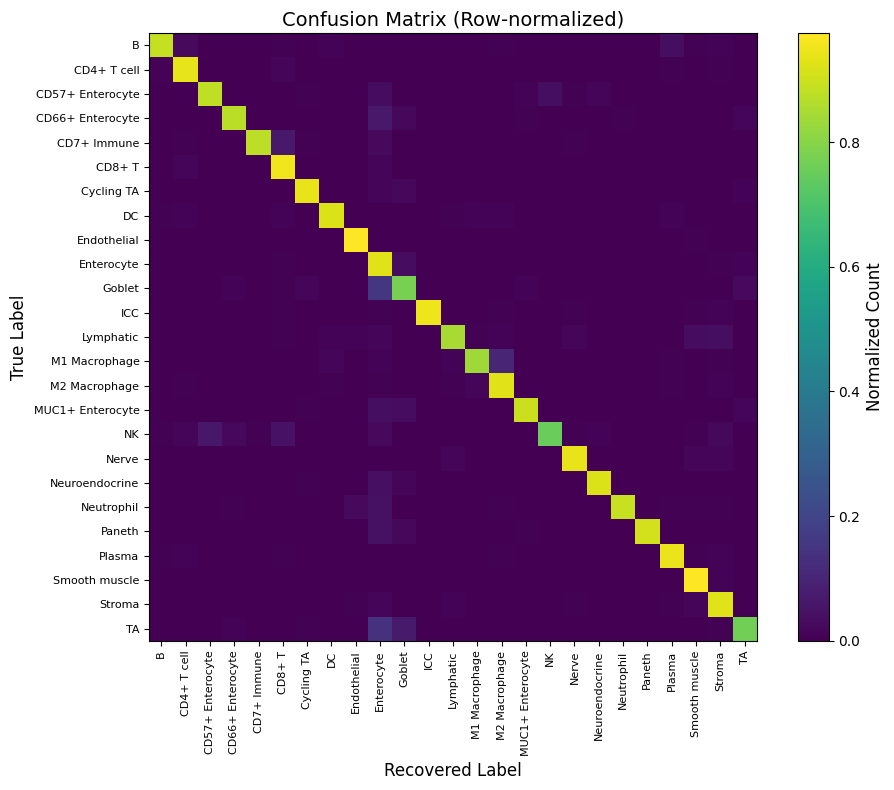

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#
# ---- 0-1 ----
normalized_cm = confusion_matrix / confusion_matrix.sum(axis=1, keepdims=True)

#
fig, ax = plt.subplots(figsize=(10, 8))

#
im = ax.imshow(normalized_cm, cmap="viridis")

#
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

#
ax.set_xticklabels(class_names, rotation=90, fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)

#
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized Count", fontsize=12)

#
ax.set_title("Confusion Matrix (Row-normalized)", fontsize=14)

#  x, y label
ax.set_xlabel("Recovered Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.savefig("confusion_matrix_normalized_heatmap.png", dpi=300)
plt.show()


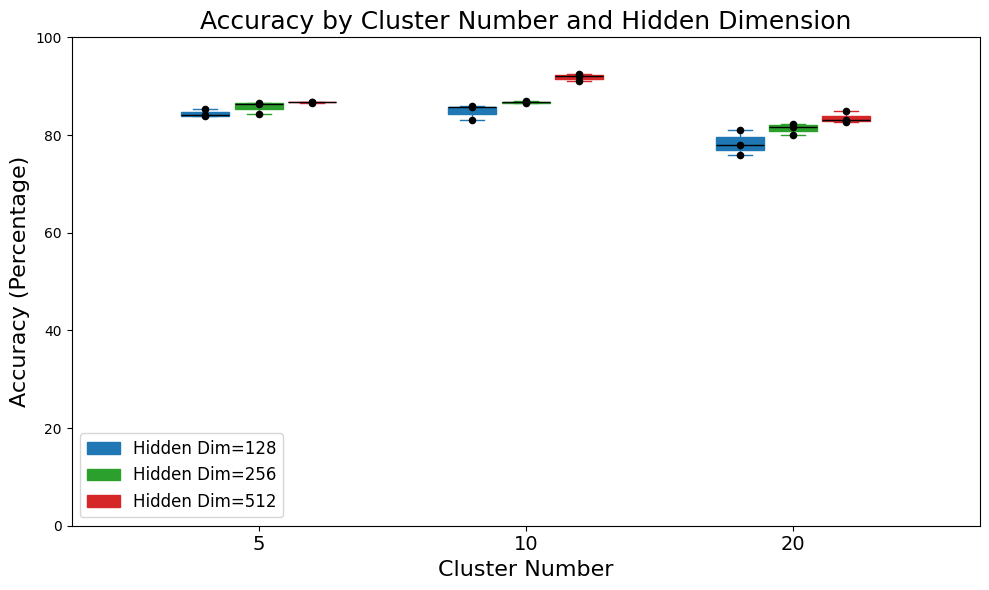

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
cluster_numbers = [5, 10, 20]
hidden_dims = [128, 256, 512]
colors = ['#1f77b4', '#2ca02c', '#d62728']   # 蓝绿红

# 存储数据
data = {
    128: {
        5: [84, 85.4, 83.8],
        10: [83, 85.78, 85.85],
        20: [78, 76, 81],
    },
    256: {
        5: [84.28, 86.4, 86.53],
        10: [87, 86.48, 86.67],
        20: [80, 81.6, 82.3],
    },
    512: {
        5: [86.6, 86.77, 86.75],
        10: [91, 92.4, 92],
        20: [82.7, 83, 84.9],
    }
}

# 准备绘图
fig, ax = plt.subplots(figsize=(10,6))

# 每组 cluster_number 的位置
x_positions = np.arange(len(cluster_numbers))

# 宽度分配
width = 0.2

for i, hidden_dim in enumerate(hidden_dims):
    # 从每个 cluster_number 提取 3 个值
    values = [data[hidden_dim][c] for c in cluster_numbers]
    # 求 boxplot 数据
    box_data = values

    # 为每组 cluster_number 平移位置
    positions = x_positions + (i - 1) * width

    # 绘制 boxplot
    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=width*0.9,
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], color=colors[i]),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=colors[i]),
        capprops=dict(color=colors[i]),
        flierprops=dict(marker='o', color=colors[i], alpha=0.5),
    )

    # 绘制点
    for j, ylist in enumerate(box_data):
        x_points = np.repeat(positions[j], len(ylist))
        ax.scatter(x_points, ylist, color='black', s=20, zorder=3)

# 设置横轴
ax.set_xticks(x_positions)
ax.set_xticklabels([str(c) for c in cluster_numbers], fontsize=14)
ax.set_xlabel('Cluster Number', fontsize=16)
ax.set_ylabel('Accuracy (Percentage)', fontsize=16)
ax.set_ylim(0, 100)
ax.legend([plt.Rectangle((0,0),1,1,color=c) for c in colors],
          [f"Hidden Dim={hd}" for hd in hidden_dims],
          fontsize=12)

ax.set_title("Accuracy by Cluster Number and Hidden Dimension", fontsize=18)

plt.tight_layout()
plt.savefig("accuracy_by_cluster_number_and_hidden_dim.png")
plt.show()


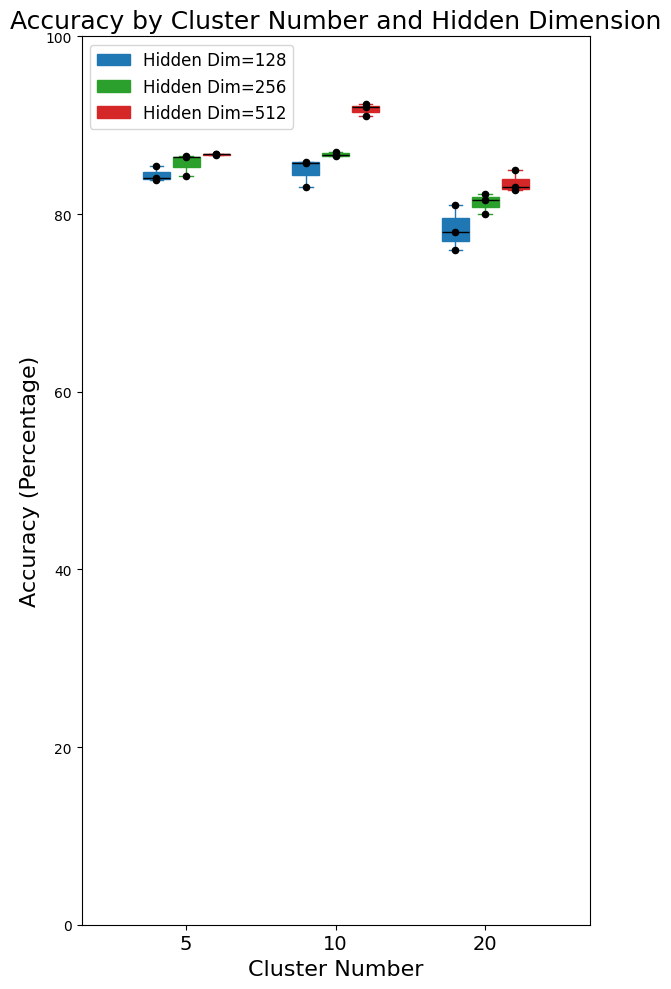

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
cluster_numbers = [5, 10, 20]
hidden_dims = [128, 256, 512]
colors = ['#1f77b4', '#2ca02c', '#d62728']   # 蓝绿红

data = {
    128: {
        5: [84, 85.4, 83.8],
        10: [83, 85.78, 85.85],
        20: [78, 76, 81],
    },
    256: {
        5: [84.28, 86.4, 86.53],
        10: [87, 86.48, 86.67],
        20: [80, 81.6, 82.3],
    },
    512: {
        5: [86.6, 86.77, 86.75],
        10: [91, 92.4, 92],
        20: [82.7, 83, 84.9],
    }
}

fig, ax = plt.subplots(figsize=(6,10))  # 调整比例：x短，y长

x_positions = np.arange(len(cluster_numbers))
width = 0.2

for i, hidden_dim in enumerate(hidden_dims):
    values = [data[hidden_dim][c] for c in cluster_numbers]
    box_data = values
    positions = x_positions + (i - 1) * width

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=width*0.9,
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], color=colors[i]),
        medianprops=dict(color='black'),
        whiskerprops=dict(color=colors[i]),
        capprops=dict(color=colors[i]),
        flierprops=dict(marker='o', color=colors[i], alpha=0.5),
    )

    # 绘制散点
    for j, ylist in enumerate(box_data):
        x_points = np.repeat(positions[j], len(ylist))
        ax.scatter(x_points, ylist, color='black', s=20, zorder=3)

ax.set_xticks(x_positions)
ax.set_xticklabels([str(c) for c in cluster_numbers], fontsize=14)
ax.set_xlabel('Cluster Number', fontsize=16)
ax.set_ylabel('Accuracy (Percentage)', fontsize=16)
ax.set_ylim(0, 100)

ax.legend([plt.Rectangle((0,0),1,1,color=c) for c in colors],
          [f"Hidden Dim={hd}" for hd in hidden_dims],
          fontsize=12)

ax.set_title("Accuracy by Cluster Number and Hidden Dimension", fontsize=18)

plt.tight_layout()
plt.show()


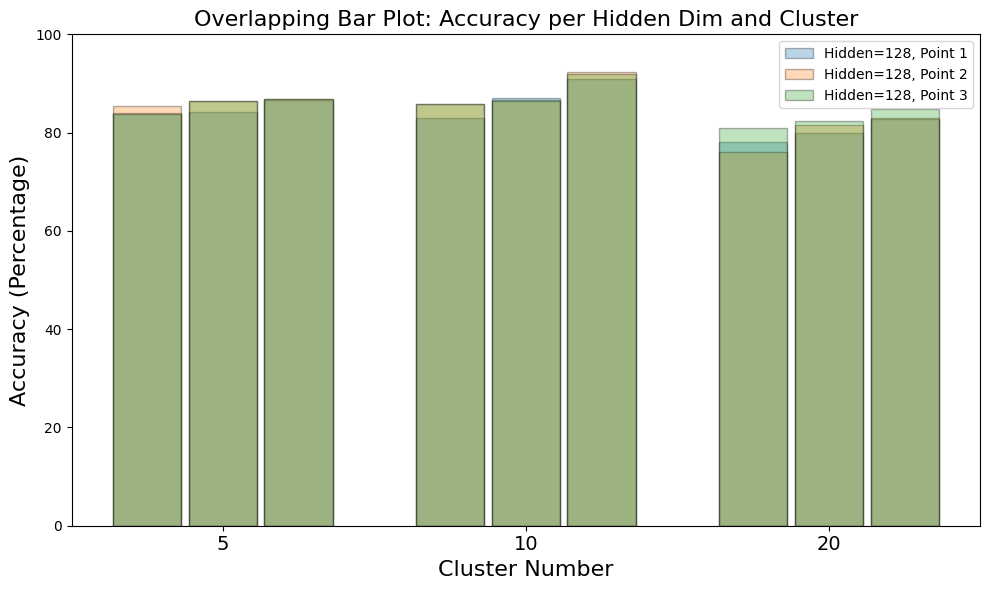

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
cluster_numbers = [5, 10, 20]
hidden_dims = [128, 256, 512]
colors_hidden_dim = ['#1f77b4', '#2ca02c', '#d62728']   # hidden_dim颜色
colors_points = ['#1f77b4', '#ff7f0e', '#2ca02c']       # 区分3个点的颜色

# 存储数据
data = {
    128: {
        5: [84, 85.4, 83.8],
        10: [83, 85.78, 85.85],
        20: [78, 76, 81],
    },
    256: {
        5: [84.28, 86.4, 86.53],
        10: [87, 86.48, 86.67],
        20: [80, 81.6, 82.3],
    },
    512: {
        5: [86.6, 86.77, 86.75],
        10: [91, 92.4, 92],
        20: [82.7, 83, 84.9],
    }
}

# cluster_number 的位置
x_positions = np.arange(len(cluster_numbers))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10,6))

for i, hidden_dim in enumerate(hidden_dims):
    positions = x_positions + (i - 1) * bar_width

    for j in range(3):
        heights = [data[hidden_dim][c][j] for c in cluster_numbers]
        ax.bar(
            positions,
            heights,
            width=bar_width*0.9,
            color=colors_points[j],
            edgecolor='black',
            alpha=0.3,  # 半透明，便于看重叠
            label=f"Hidden={hidden_dim}, Point {j+1}" if i==0 else None,
        )

# 横轴
ax.set_xticks(x_positions)
ax.set_xticklabels([str(c) for c in cluster_numbers], fontsize=14)
ax.set_xlabel('Cluster Number', fontsize=16)
ax.set_ylabel('Accuracy (Percentage)', fontsize=16)
ax.set_ylim(0, 100)

# 去掉重复 legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), fontsize=10)

ax.set_title("Overlapping Bar Plot: Accuracy per Hidden Dim and Cluster", fontsize=16)

plt.tight_layout()
plt.savefig("overlapping_bar_plot.png")
plt.show()


/tmp/ipython-input-2792602198.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


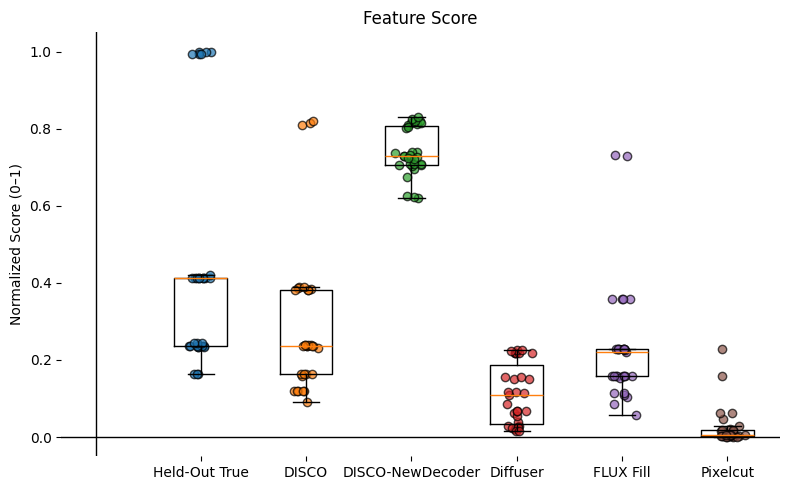

/tmp/ipython-input-2792602198.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


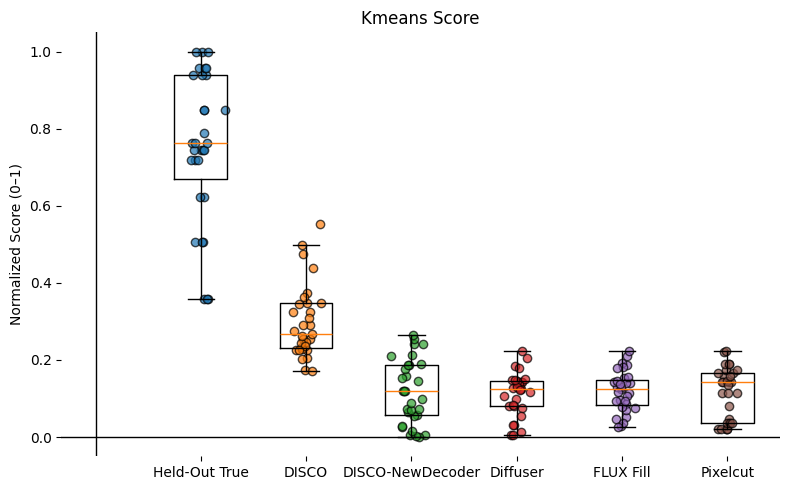

/tmp/ipython-input-2792602198.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


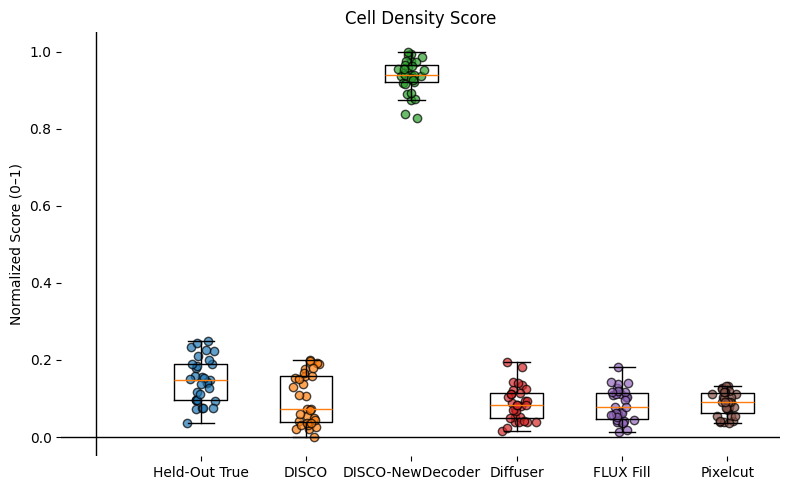

/tmp/ipython-input-2792602198.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


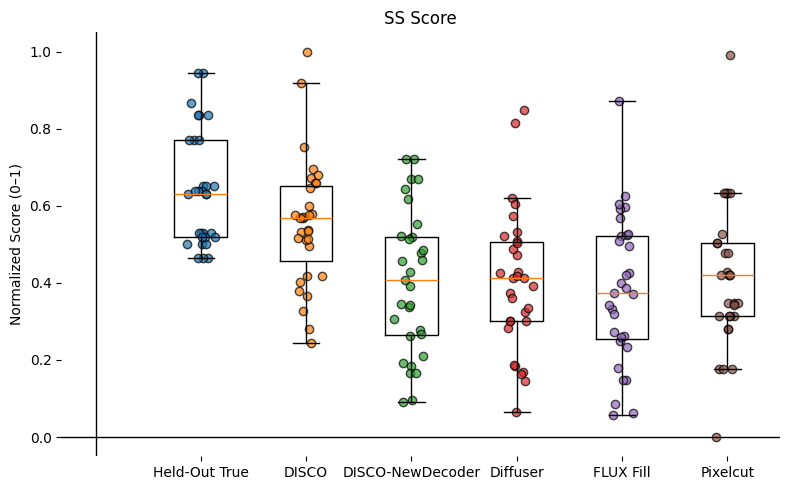

/tmp/ipython-input-2792602198.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


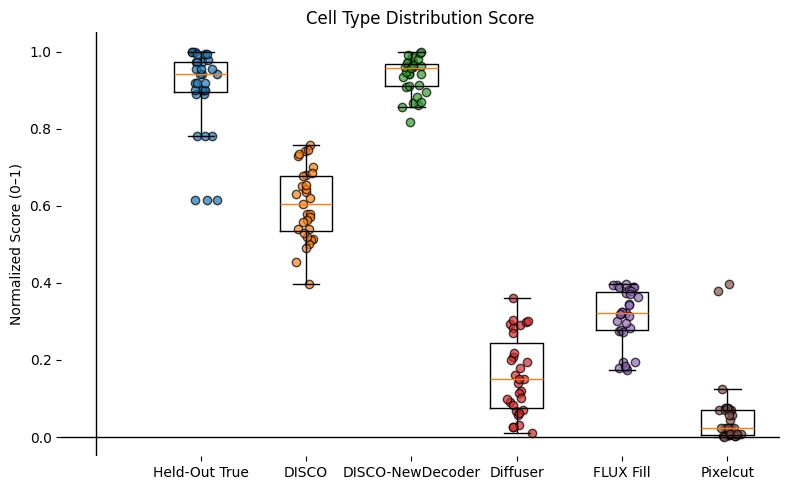

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np

# Ensure reproducibility
np.random.seed(42)

# ==== 文件路径 ====
diffuser_file = 'diffuser1.txt'
flux_file = 'FLUX FIll1.txt'
pixelcut_file = 'pixelcut1.txt'
new_file = 'new.txt'  # 新文件，解析为 DISCO-NewDecoder

# ==== 指标 ====
metrics = [
    'Feature Score',
    'Kmeans Score',
    'Cell Density Score',
    'SS Score',
    'Cell Type Distribution Score'
]

# ==== 方法顺序（DISCO-NewDecoder 放在第二列） ====
methods = ['Held-Out True', 'DISCO-NewDecoder', 'DISCO', 'Diffuser', 'FLUX Fill', 'Pixelcut']

# ==== 初始化数据结构 ====
raw_data = {metric: {m: [] for m in methods} for metric in metrics}

# ==== 从 diffuser 文件读取 ====
with open(diffuser_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()
for line in lines:
    for metric in metrics:
        if metric in line:
            match = re.search(r'\[(.*?)\]', line)
            if match:
                nums = [float(x) for x in match.group(1).split(',')]
                # 假设 diffuser 行列: [Held-Out, DISCO, Diffuser, ...]
                raw_data[metric]['Held-Out True'].append(nums[0])
                raw_data[metric]['DISCO'].append(nums[1])
                raw_data[metric]['Diffuser'].append(nums[2])

# ==== 从 new.txt 文件读取 (DISCO-NewDecoder) ====
with open(new_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()
for line in lines:
    for metric in metrics:
        if metric in line:
            match = re.search(r'\[(.*?)\]', line)
            if match:
                nums = [float(x) for x in match.group(1).split(',')]
                # 将 new.txt 的第 2 列 (nums[1]) 作为 DISCO-NewDecoder
                raw_data[metric]['DISCO-NewDecoder'].append(nums[1])

# ==== 从 FLUX Fill 文件读取 ====
with open(flux_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()
for line in lines:
    for metric in metrics:
        if metric in line:
            match = re.search(r'\[(.*?)\]', line)
            if match:
                nums = [float(x) for x in match.group(1).split(',')]
                # 取最后一列作为 FLUX Fill 的值（与你原脚本一致）
                raw_data[metric]['FLUX Fill'].append(nums[-1])

# ==== 从 pixelcut 文件读取 ====
with open(pixelcut_file, 'r', encoding='utf-8') as f:
    lines = f.readlines()
for line in lines:
    for metric in metrics:
        if metric in line:
            match = re.search(r'\[(.*?)\]', line)
            if match:
                nums = [float(x) for x in match.group(1).split(',')]
                raw_data[metric]['Pixelcut'].append(nums[-1])

# ==== 归一化并绘图 ====
for metric in metrics:
    # 防止方法某些 list 为空，先过滤非空值用于 min/max
    all_vals_collected = []
    for m in methods:
        all_vals_collected.extend(raw_data[metric][m])
    if len(all_vals_collected) == 0:
        print(f"Warning: no values found for metric '{metric}'. Skipping.")
        continue

    min_val, max_val = min(all_vals_collected), max(all_vals_collected)
    # 若 max==min（常量），避免除 0，直接置为 0.5
    def normalize_list(lst):
        if len(lst) == 0:
            return []
        if max_val == min_val:
            return [0.5 for _ in lst]
        return [(v - min_val) / (max_val - min_val) for v in lst]

    norm_data = {m: normalize_list(raw_data[metric][m]) for m in methods}

    # ==== 绘图 ====
    plt.figure(figsize=(9, 6))
    box_data = [norm_data[m] if len(norm_data[m])>0 else [np.nan] for m in methods]
    # 使用 nan 填充为空方法，以保证 boxplot 能画出每个位置（但会显示空）
    plt.boxplot(box_data, labels=methods, showfliers=False)

    # 散点分布（按方法顺序 jitter）
    for i, m in enumerate(methods, start=1):
        y = norm_data[m]
        if len(y) == 0:
            continue
        x = np.random.normal(loc=i, scale=0.06, size=len(y))
        plt.scatter(x, y, edgecolor='black', alpha=0.7)

    # 美化：移除四周边框但保留轴线
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

    plt.ylabel('Normalized Score (0–1)')
    plt.title(metric)
    plt.xticks(rotation=30)
    plt.grid(False)
    plt.tight_layout()
    filename = f"{metric.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    plt.show()
    print(f"Saved plot: {filename}")


In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

# 方法与指标
metrics = [
    'Feature Score',
    'Kmeans Score',
    'Cell Density Score',
    'SS Score',
    'Cell Type Distribution Score'
]
methods = ['DISCO','DISCO-VAE', 'Diffuser', 'FLUX Fill']

# 原始数据结构
raw_data = {metric: {m: [] for m in methods} for metric in metrics}

# ----------- 读取数据 -----------
# diffuser1.txt
with open('merfish.txt', 'r', encoding='utf-8') as f:
    for line in f:
        for metric in metrics:
            if metric in line:
                match = re.search(r'\[(.*?)\]', line)
                if match:
                    nums = [float(x) for x in match.group(1).split(',')]
                    raw_data[metric]['DISCO'].append(nums[0])
                    raw_data[metric]['Diffuser'].append(nums[2])
                    raw_data[metric]['FLUX Fill'].append(nums[1])


with open('merfish1.txt', 'r', encoding='utf-8') as f:
    for line in f:
        for metric in metrics:
            if metric in line:
                match = re.search(r'\[(.*?)\]', line)
                if match:
                    nums = [float(x) for x in match.group(1).split(',')]
                    raw_data[metric]['DISCO-VAE'].append(nums[0])


# ----------- 作图与统计检验 -----------
for metric in metrics:
    # 归一化
    #all_vals = [v for m in methods for v in raw_data[metric][m]]
    #min_val, max_val = min(all_vals), max(all_vals)
    #norm_data = {
    #   m: [(v - min_val) / (max_val - min_val) for v in raw_data[metric][m]]
    #    for m in methods
    #}
    norm_data = raw_data

    # 作图
    plt.figure(figsize=(8, 5))
    data_for_plot = [norm_data[m] for m in methods]
    plt.boxplot(data_for_plot, labels=methods, showfliers=False)

    # 散点
    for i, m in enumerate(methods, start=1):
        x = np.random.normal(loc=i, scale=0.06, size=len(norm_data[m]))
        y = norm_data[m]
        plt.scatter(x, y, edgecolor='black', alpha=0.7)

    # 显著性标注：DISCO vs 其他方法（不包括 Held-Out True）
    y_max = max([max(v) for v in norm_data.values()])
    comparisons = [('DISCO', m) for m in methods if m not in ['DISCO']]
    for i, (m1, m2) in enumerate(comparisons):
        stat, p = ttest_ind(norm_data[m1], norm_data[m2])
        # 横线和文字
        x1 = methods.index(m1) + 1
        x2 = methods.index(m2) + 1
        y = y_max + 0.05 + i * 0.08
        h = 0.01
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c='black')
        if p < 0.001:
          text = "p < 0.001"
        else:
          text = f"p = {p:.3f}"

        plt.text((x1 + x2) / 2, y + h + 0.002, text, ha='center', va='bottom', fontsize=9)

    # 美化
    plt.title(metric)
    plt.ylabel("Normalized Score (0–1)")
    plt.xticks(rotation=30)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f"{metric}_pval_only.png", dpi=300)
    plt.show()


KeyError: 'DISCO'

<Figure size 800x500 with 0 Axes>

/tmp/ipython-input-1853873268.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_plot, labels=methods, showfliers=False)


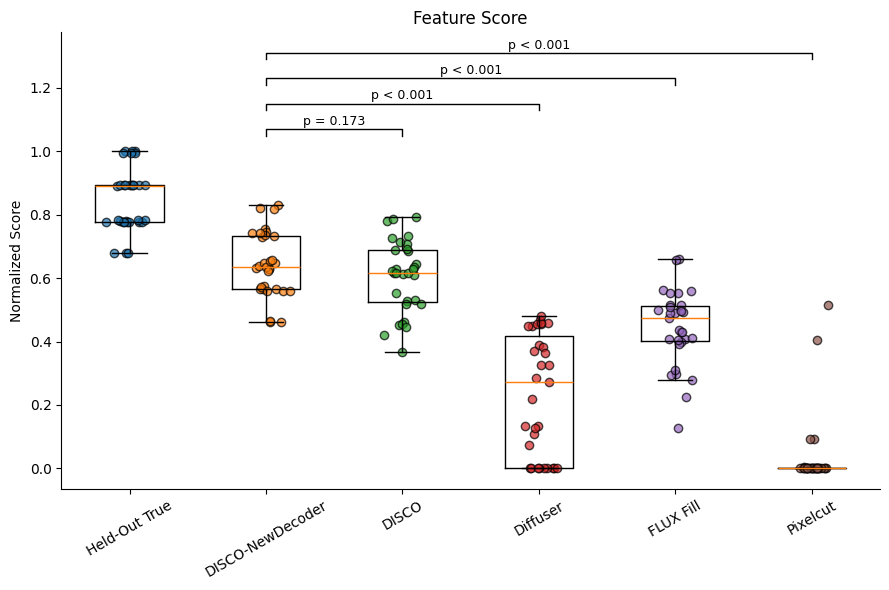

✅ Saved plot: Feature_Score_norm_pval_DISCO-NewDecoder.png


/tmp/ipython-input-1853873268.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_plot, labels=methods, showfliers=False)


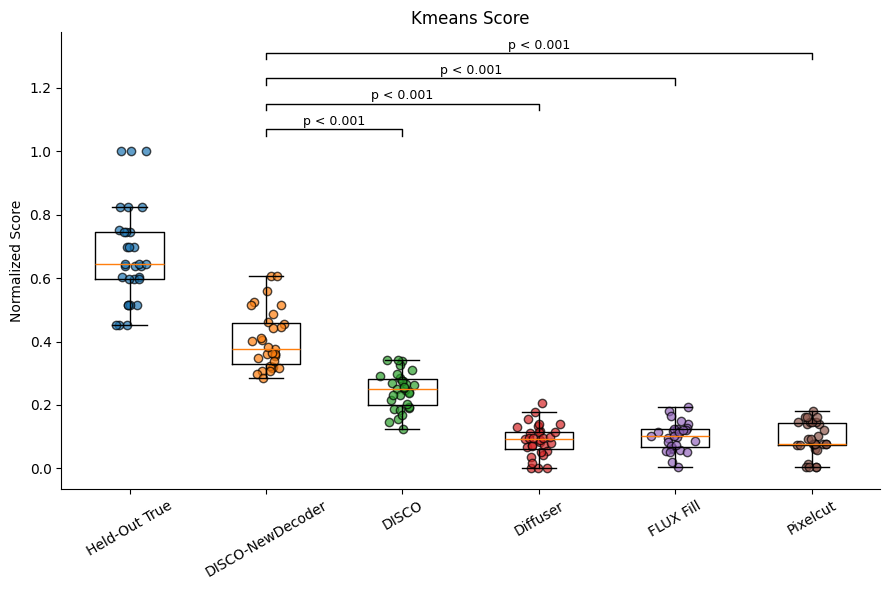

✅ Saved plot: Kmeans_Score_norm_pval_DISCO-NewDecoder.png


/tmp/ipython-input-1853873268.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_plot, labels=methods, showfliers=False)


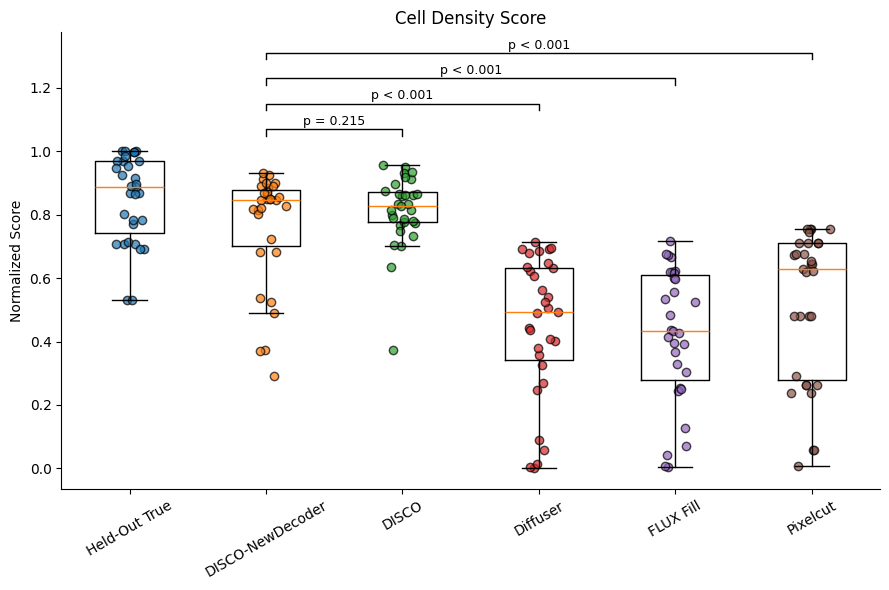

✅ Saved plot: Cell_Density_Score_norm_pval_DISCO-NewDecoder.png


/tmp/ipython-input-1853873268.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_plot, labels=methods, showfliers=False)


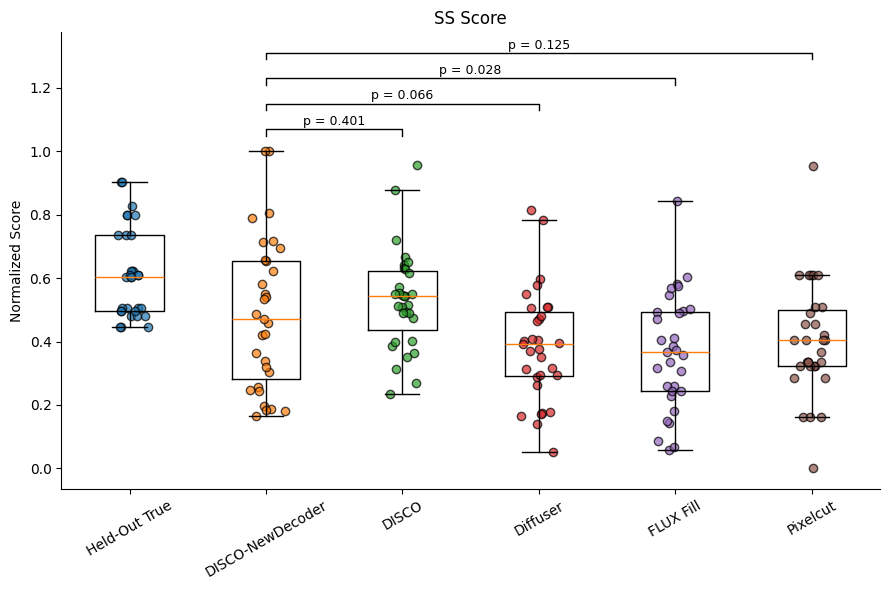

✅ Saved plot: SS_Score_norm_pval_DISCO-NewDecoder.png


/tmp/ipython-input-1853873268.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_plot, labels=methods, showfliers=False)


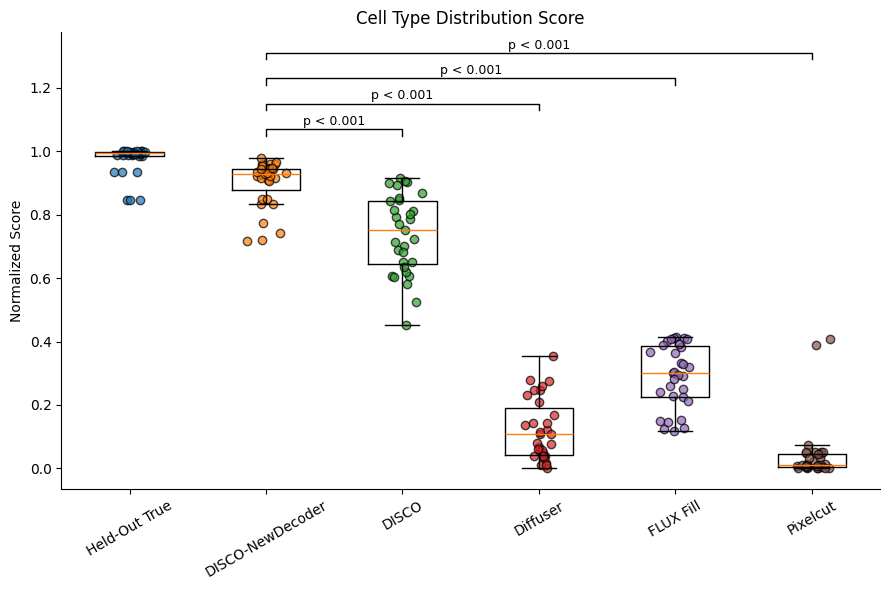

✅ Saved plot: Cell_Type_Distribution_Score_norm_pval_DISCO-NewDecoder.png


In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

# 方法与指标
metrics = [
    'Feature Score',
    'Kmeans Score',
    'Cell Density Score',
    'SS Score',
    'Cell Type Distribution Score'
]

methods = ['Held-Out True', 'DISCO-NewDecoder', 'DISCO', 'Diffuser', 'FLUX Fill', 'Pixelcut']

raw_data = {metric: {m: [] for m in methods} for metric in metrics}

# ----------- 读取数据 -----------

with open('d1.txt', 'r', encoding='utf-8') as f:
    for line in f:
        for metric in metrics:
            if metric in line:
                match = re.search(r'\[(.*?)\]', line)
                if match:
                    nums = [float(x) for x in match.group(1).split(',')]

                    raw_data[metric]['Diffuser'].append(nums[2])

with open('new1.txt', 'r', encoding='utf-8') as f:
    for line in f:
        for metric in metrics:
            if metric in line:
                match = re.search(r'\[(.*?)\]', line)
                if match:
                    nums = [float(x) for x in match.group(1).split(',')]
                    raw_data[metric]['DISCO-NewDecoder'].append(nums[-1])
                    raw_data[metric]['DISCO'].append(nums[1])
                    raw_data[metric]['Held-Out True'].append(nums[0])

with open('f1.txt', 'r', encoding='utf-8') as f:
    for line in f:
        for metric in metrics:
            if metric in line:
                match = re.search(r'\[(.*?)\]', line)
                if match:
                    nums = [float(x) for x in match.group(1).split(',')]
                    raw_data[metric]['FLUX Fill'].append(nums[-1])

with open('p1.txt', 'r', encoding='utf-8') as f:
    for line in f:
        for metric in metrics:
            if metric in line:
                match = re.search(r'\[(.*?)\]', line)
                if match:
                    nums = [float(x) for x in match.group(1).split(',')]
                    raw_data[metric]['Pixelcut'].append(nums[-1])

# ----------- 作图与统计检验 -----------

for metric in metrics:
    # 合并所有值，便于归一化
    all_vals = [v for m in methods for v in raw_data[metric][m]]
    if len(all_vals) == 0:
        print(f"⚠️ No values for metric '{metric}', skipping.")
        continue

    # ----------- Min-Max Normalization -----------
    min_val = min(all_vals)
    max_val = max(all_vals)
    if max_val - min_val == 0:
        print(f"⚠️ Metric '{metric}' has constant values, skipping normalization.")
        continue

    for m in methods:
        raw_data[metric][m] = [(v - min_val) / (max_val - min_val) for v in raw_data[metric][m]]

    data_for_plot = [raw_data[metric][m] for m in methods]

    # ----------- 绘图 -----------
    plt.figure(figsize=(9, 6))
    plt.boxplot(data_for_plot, labels=methods, showfliers=False)

    # Scatter jitter
    for i, m in enumerate(methods, start=1):
        y = raw_data[metric][m]
        if len(y) == 0:
            continue
        x = np.random.normal(loc=i, scale=0.06, size=len(y))
        plt.scatter(x, y, edgecolor='black', alpha=0.7)

    # 显著性标注：DISCO-NewDecoder vs 其他方法
    base_method = 'DISCO-NewDecoder'
    compare_methods = [m for m in methods if m not in ['Held-Out True', base_method]]
    y_max = max([max(v) for v in raw_data[metric].values() if len(v) > 0])

    for i, m2 in enumerate(compare_methods):
        data1 = raw_data[metric][base_method]
        data2 = raw_data[metric][m2]
        if len(data1) < 2 or len(data2) < 2:
            print(f"Skipping t-test for {base_method} vs {m2} on '{metric}' (too few samples)")
            continue

        stat, p = ttest_ind(data1, data2, equal_var=False)
        x1 = methods.index(base_method) + 1
        x2 = methods.index(m2) + 1
        y = y_max + 0.05 + i * 0.08
        h = 0.02
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c='black')

        if p < 0.001:
            text = "p < 0.001"
        else:
            text = f"p = {p:.3f}"
        plt.text((x1 + x2) / 2, y + h + 0.005, text, ha='center', va='bottom', fontsize=9)

    plt.title(metric)
    plt.ylabel("Normalized Score")
    plt.xticks(rotation=30)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.grid(False)
    plt.tight_layout()
    filename = f"{metric.replace(' ', '_')}_norm_pval_DISCO-NewDecoder.png"
    plt.savefig(filename, dpi=300)
    plt.show()
    print(f"✅ Saved plot: {filename}")


/tmp/ipython-input-4-1671164826.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


Feature Score


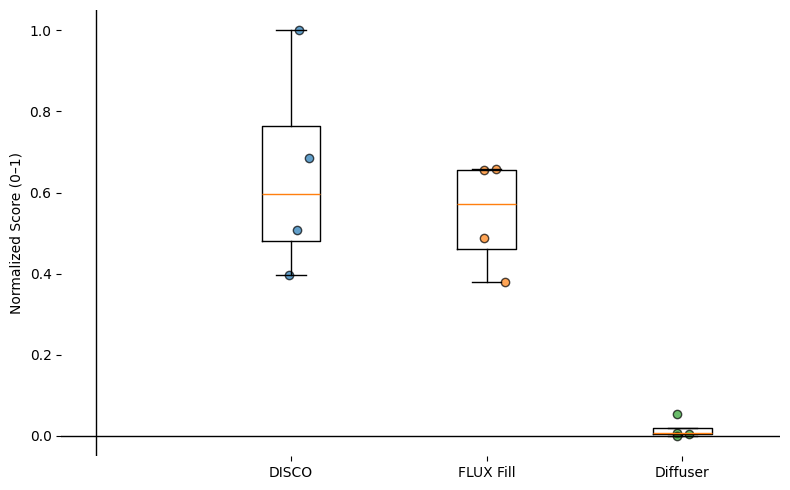

Kmeans Score


/tmp/ipython-input-4-1671164826.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


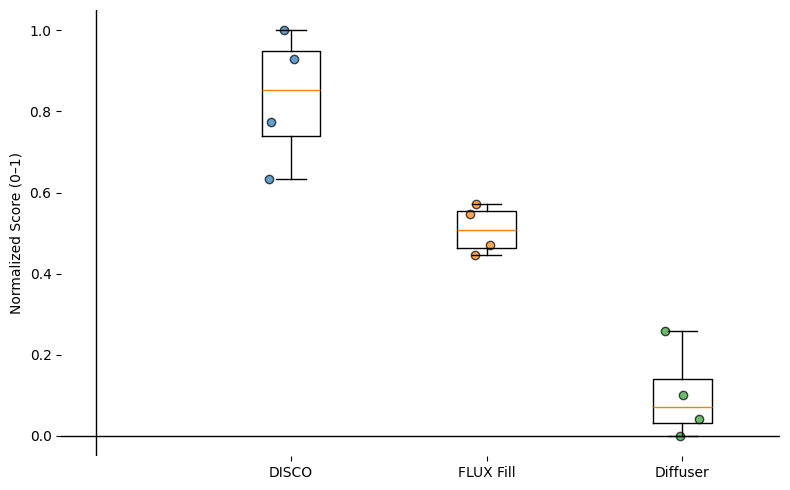

/tmp/ipython-input-4-1671164826.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


Cell Density Score


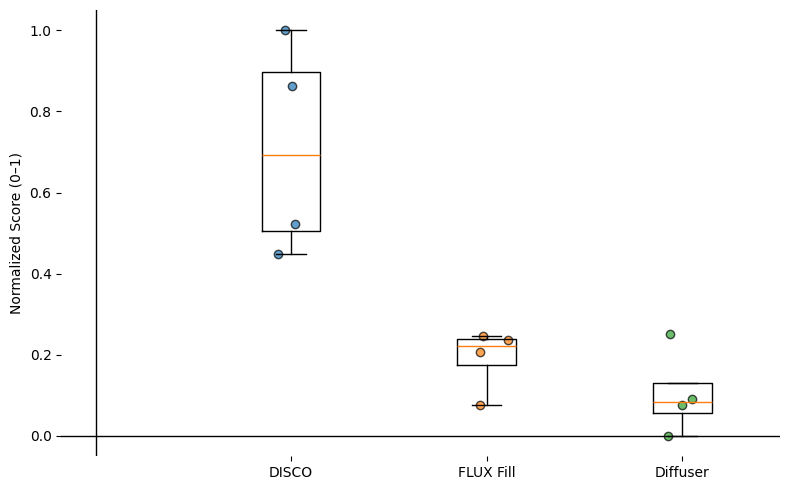

/tmp/ipython-input-4-1671164826.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


SS Score


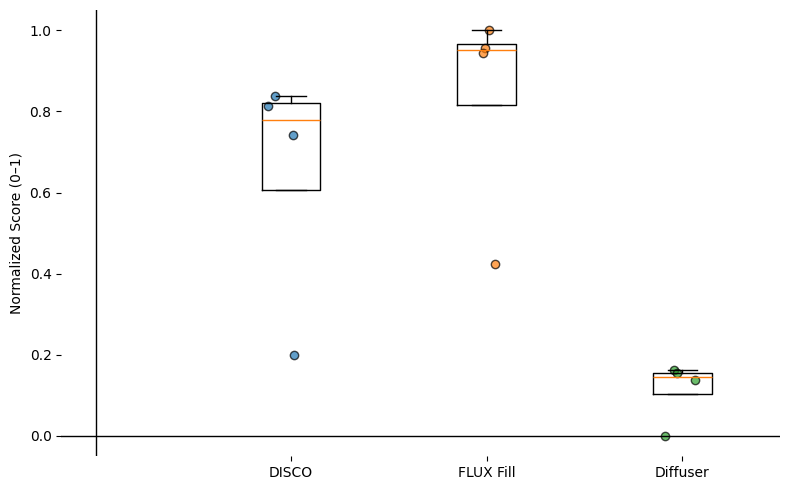

/tmp/ipython-input-4-1671164826.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


Cell Type Distribution Score


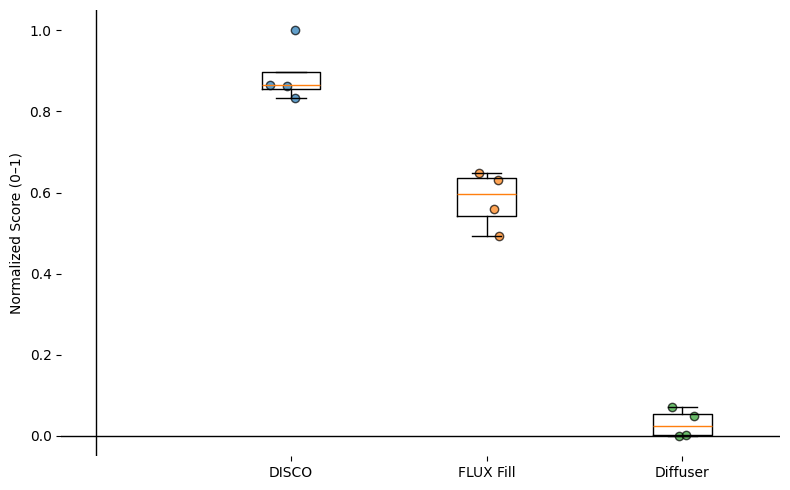

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np

# Ensure reproducibility
np.random.seed(42)

# File paths
file = 'eval_m.txt'


# Metrics to normalize and plot
metrics = [
    'Feature Score',
    'Kmeans Score',
    'Cell Density Score',
    'SS Score',
    'Cell Type Distribution Score'
]

# Methods
methods = ['DISCO', 'FLUX Fill', 'Diffuser']

# Extract raw data
raw_data = {metric: {m: [] for m in methods} for metric in metrics}

with open(file, 'r', encoding='utf-8') as f:
    lines = f.readlines()
for line in lines:
    for metric in metrics:
        if metric in line:
            match = re.search(r'\[(.*?)\]', line)
            if match:
                nums = [float(x) for x in match.group(1).split(',')]
                raw_data[metric]['DISCO'].append(nums[0])
                raw_data[metric]['FLUX Fill'].append(nums[1])
                raw_data[metric]['Diffuser'].append(nums[2])

# Normalize and plot
for metric in metrics:
    # Gather all values to compute min and max
    all_vals = [v for m in methods for v in raw_data[metric][m]]
    min_val, max_val = min(all_vals), max(all_vals)

    # Normalize data
    norm_data = {
        m: [(v - min_val) / (max_val - min_val) for v in raw_data[metric][m]]
        for m in methods
    }

    # Plot
    plt.figure(figsize=(8, 5))
    plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)

    # Scatter points
    for i, m in enumerate(methods, start=1):
      y = norm_data[m]
      x = np.random.normal(loc=i, scale=0.06, size=len(y))
      plt.scatter(x, y, edgecolor='black', alpha=0.7)

    # ---- 去掉四周边框 ----
    ax = plt.gca()
    for spine in ax.spines.values():
      spine.set_visible(False)

    # 保留 X、Y 轴线
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)

    # 可选：只显示 ticks，不显示外框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 只显示 ticks
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

    # 删掉标题，保留 axis label
    print(metric)
    plt.ylabel('Normalized Score (0–1)')

    # 去掉 grid
    plt.grid(False)

    plt.tight_layout()
    plt.savefig(f"{metric}.png")
    plt.show()



Cell Type Distribution Score


/tmp/ipython-input-3-3761208942.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)


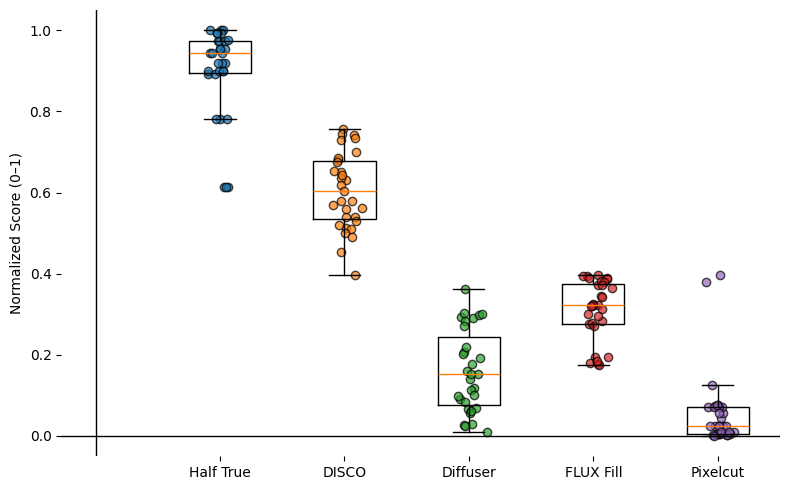

In [ ]:
# Plot
plt.figure(figsize=(8, 5))
plt.boxplot([norm_data[m] for m in methods], labels=methods, showfliers=False)

# Scatter points
for i, m in enumerate(methods, start=1):
    y = norm_data[m]
    x = np.random.normal(loc=i, scale=0.06, size=len(y))
    plt.scatter(x, y, edgecolor='black', alpha=0.7)

# ---- 去掉四周边框 ----
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# 保留 X、Y 轴线
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# 可选：只显示 ticks，不显示外框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 只显示 ticks
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

# 删掉标题，保留 axis label
print(metric)
plt.ylabel('Normalized Score (0–1)')

# 去掉 grid
plt.grid(False)

plt.tight_layout()
plt.savefig(f"{metric}.png")
plt.show()


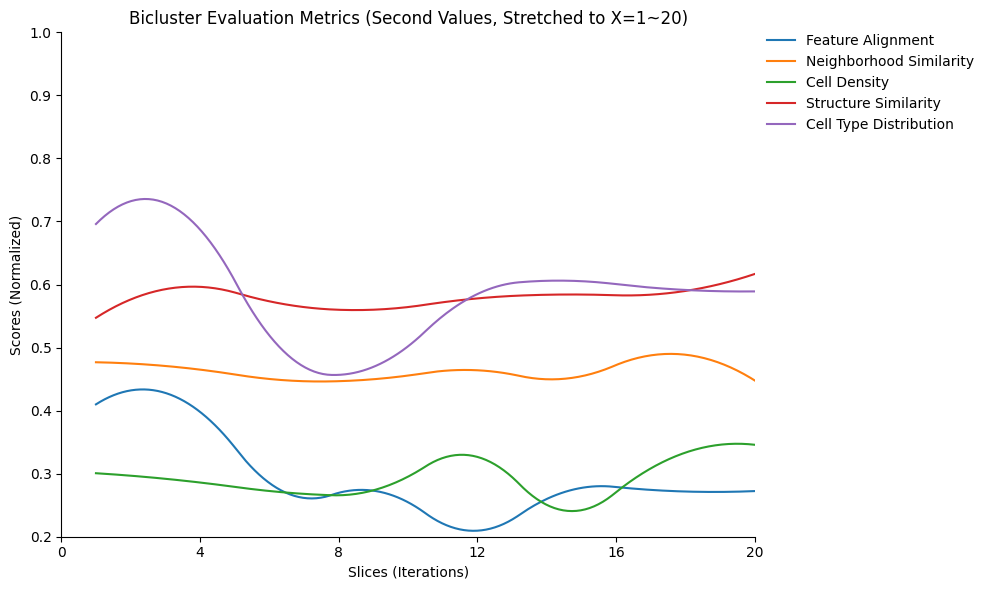

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# 数据（新数据）
raw_data = [
    {
        "Feature": 0.2723904382982439,
        "Kmeans": 0.22381158617064248,
        "CellDensity": 0.17290395673986478,
        "SS": 0.6168302297592163,
        "CellTypeDist": 0.5890812874208075
    },
    {
        "Feature": 0.2733184782818046,
        "Kmeans": 0.24471278068092714,
        "CellDensity": 0.1584452550203198,
        "SS": 0.5850947499275208,
        "CellTypeDist": 0.5938715270414784
    },
    {
        "Feature": 0.2719507485075281,
        "Kmeans": 0.2254387751113505,
        "CellDensity": 0.12055514226460591,
        "SS": 0.5841768383979797,
        "CellTypeDist": 0.6060767649749799
    },
    {
        "Feature": 0.20940924814280587,
        "Kmeans": 0.2321573282583718,
        "CellDensity": 0.16418721765473065,
        "SS": 0.5772659480571747,
        "CellTypeDist": 0.5810625899552752
    },
    {
        "Feature": 0.27170531836775974,
        "Kmeans": 0.2252170877712598,
        "CellDensity": 0.13794884573371058,
        "SS": 0.560396820306778,
        "CellTypeDist": 0.47285736253913896
    },
    {
        "Feature": 0.2709943905281549,
        "Kmeans": 0.22410944013051282,
        "CellDensity": 0.13514691760604428,
        "SS": 0.5688410103321075,
        "CellTypeDist": 0.49327728186283665
    },
    {
        "Feature": 0.4092669620423265,
        "Kmeans": 0.2334470938628914,
        "CellDensity": 0.14388788186462012,
        "SS": 0.5965723991394043,
        "CellTypeDist": 0.703257223850548
    },
    {
        "Feature": 0.40993832695962446,
        "Kmeans": 0.2383574973093402,
        "CellDensity": 0.15035581932906683,
        "SS": 0.5472634732723236,
        "CellTypeDist": 0.6959677074169371
    }
]

metrics = ["Feature", "Kmeans", "CellDensity", "SS", "CellTypeDist"]
pretty_names = {
    "Feature": "Feature Alignment",
    "Kmeans": "Neighborhood Similarity",
    "CellDensity": "Cell Density",
    "SS": "Structure Similarity",
    "CellTypeDist": "Cell Type Distribution"
}

data_dict = {m: [] for m in metrics}

# 提取 second values
for group in raw_data:
    for m in metrics:
        data_dict[m].append(group[m])

# 倒序
for m in metrics:
    data_dict[m] = data_dict[m][::-1]

# 放大因子
scale_factors = {
    "Feature": 1,
    "Kmeans": 2,
    "CellDensity": 2,
    "SS": 1,
    "CellTypeDist": 1
}

# 应用放大因子
for m in metrics:
    data_dict[m] = [v * scale_factors[m] for v in data_dict[m]]

# 原始横坐标
x_original = np.arange(1, 9)

# 拉伸到 1-20
# 映射公式: x_new = 1 + (x_old - 1)*(19/7)
x_new_stretched = 1 + (x_original - 1) * (19/7)

# 曲线平滑
x_interp = np.linspace(1, 20, 300)

# 绘制曲线图
plt.figure(figsize=(10, 6))

for m in metrics:
    y = np.array(data_dict[m])
    f_interp = interp1d(x_new_stretched, y, kind='quadratic', bounds_error=False, fill_value="extrapolate")
    y_interp = f_interp(x_interp)
    plt.plot(x_interp, y_interp, label=pretty_names[m])

plt.xlabel("Slices (Iterations)")
plt.ylabel("Scores (Normalized)")
plt.title("Bicluster Evaluation Metrics (Second Values, Stretched to X=1~20)")

# legend 放右边
plt.legend(loc='center left', bbox_to_anchor=(1, 0.9), frameon=False)

# 设置横轴
plt.ylim(0.2, 1)
plt.xlim(1, 20)
plt.xticks(np.arange(0, 21, 4))

# 去网格
plt.grid(False)

# 去掉上右边框
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig("longslices_metrics.png",dpi=300)
plt.show()


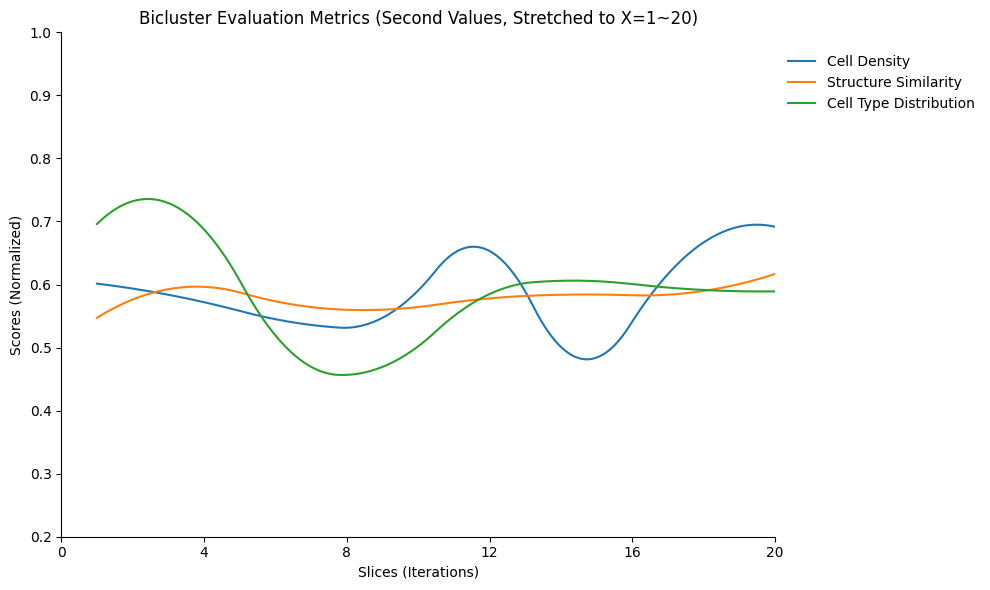

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# 数据（新数据）
raw_data = [
    {
        "CellDensity": 0.17290395673986478,
        "SS": 0.6168302297592163,
        "CellTypeDist": 0.5890812874208075
    },
    {
        "CellDensity": 0.1584452550203198,
        "SS": 0.5850947499275208,
        "CellTypeDist": 0.5938715270414784
    },
    {
        "CellDensity": 0.12055514226460591,
        "SS": 0.5841768383979797,
        "CellTypeDist": 0.6060767649749799
    },
    {
        "CellDensity": 0.16418721765473065,
        "SS": 0.5772659480571747,
        "CellTypeDist": 0.5810625899552752
    },
    {
        "CellDensity": 0.13794884573371058,
        "SS": 0.560396820306778,
        "CellTypeDist": 0.47285736253913896
    },
    {
        "CellDensity": 0.13514691760604428,
        "SS": 0.5688410103321075,
        "CellTypeDist": 0.49327728186283665
    },
    {
        "CellDensity": 0.14388788186462012,
        "SS": 0.5965723991394043,
        "CellTypeDist": 0.703257223850548
    },
    {
        "CellDensity": 0.15035581932906683,
        "SS": 0.5472634732723236,
        "CellTypeDist": 0.6959677074169371
    }
]

raw_data1 = [
    {
        "CellDensity": 0.4335122237278002,
        "SS": 0.5451541543006897,
        "CellTypeDist": 0.10323410671672996
    },
    {
        "CellDensity": 0.4273464706810136,
        "SS": 0.5237579345703125,
        "CellTypeDist": 0.10454747778368054
    },
    {
        "CellDensity": 0.41280708570090036,
        "SS": 0.51537024974823,
        "CellTypeDist": 0.12850239926922943
    },
    {
        "CellDensity": 0.41754591890664017,
        "SS": 0.49185723066329956,
        "CellTypeDist": 0.10492801362111574
    },
    {
        "CellDensity": 0.3868581660456746,
        "SS": 0.4855247139930725,
        "CellTypeDist": 0.09351648764559976
    },
    {
        "CellDensity": 0.36436483558164634,
        "SS": 0.469946026802063,
        "CellTypeDist": 0.07360132981673663
    },
    {
        "CellDensity": 0.35896829533371366,
        "SS": 0.4677707552909851,
        "CellTypeDist": 0.07676419019574102
    },
    {
        "CellDensity": 0.3575441335858397,
        "SS": 0.4484788179397583,
        "CellTypeDist": 0.09858327200327194
    }
]


metrics = ["CellDensity", "SS", "CellTypeDist"]
pretty_names = {
    "CellDensity": "Cell Density",
    "SS": "Structure Similarity",
    "CellTypeDist": "Cell Type Distribution"
}

data_dict = {m: [] for m in metrics}

# 提取 second values
for group in raw_data:
    for m in metrics:
        data_dict[m].append(group[m])

# 倒序
for m in metrics:
    data_dict[m] = data_dict[m][::-1]

# 放大因子
scale_factors = {
    "CellDensity": 4,
    "SS": 1,
    "CellTypeDist": 1
}

# 应用放大因子
for m in metrics:
    data_dict[m] = [v * scale_factors[m] for v in data_dict[m]]

# 原始横坐标
x_original = np.arange(1, 9)

# 拉伸到 1-20
# 映射公式: x_new = 1 + (x_old - 1)*(19/7)
x_new_stretched = 1 + (x_original - 1) * (19/7)

# 曲线平滑
x_interp = np.linspace(1, 20, 300)

# 绘制曲线图
plt.figure(figsize=(10, 6))

for m in metrics:
    y = np.array(data_dict[m])
    f_interp = interp1d(x_new_stretched, y, kind='quadratic', bounds_error=False, fill_value="extrapolate")
    y_interp = f_interp(x_interp)
    plt.plot(x_interp, y_interp, label=pretty_names[m])

plt.xlabel("Slices (Iterations)")
plt.ylabel("Scores (Normalized)")
plt.title("Bicluster Evaluation Metrics (Second Values, Stretched to X=1~20)")

# legend 放右边
plt.legend(loc='center left', bbox_to_anchor=(1, 0.9), frameon=False)

# 设置横轴
plt.ylim(0.2, 1)
plt.xlim(1, 20)
plt.xticks(np.arange(0, 21, 4))

# 去网格
plt.grid(False)

# 去掉上右边框
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig("longslices_metrics.png",dpi=300)
plt.show()


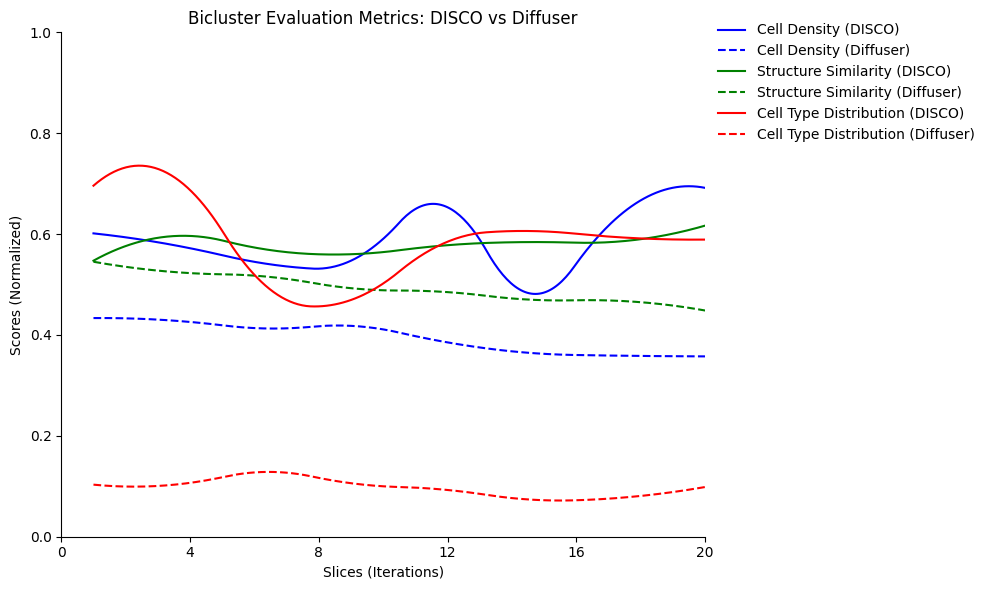

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# ========== 数据 ==========
raw_data = [
    {"CellDensity": 0.17290395673986478, "SS": 0.6168302297592163, "CellTypeDist": 0.5890812874208075},
    {"CellDensity": 0.1584452550203198, "SS": 0.5850947499275208, "CellTypeDist": 0.5938715270414784},
    {"CellDensity": 0.12055514226460591, "SS": 0.5841768383979797, "CellTypeDist": 0.6060767649749799},
    {"CellDensity": 0.16418721765473065, "SS": 0.5772659480571747, "CellTypeDist": 0.5810625899552752},
    {"CellDensity": 0.13794884573371058, "SS": 0.560396820306778, "CellTypeDist": 0.47285736253913896},
    {"CellDensity": 0.13514691760604428, "SS": 0.5688410103321075, "CellTypeDist": 0.49327728186283665},
    {"CellDensity": 0.14388788186462012, "SS": 0.5965723991394043, "CellTypeDist": 0.703257223850548},
    {"CellDensity": 0.15035581932906683, "SS": 0.5472634732723236, "CellTypeDist": 0.6959677074169371}
]

raw_data1 = [
    {"CellDensity": 0.4335122237278002, "SS": 0.5451541543006897, "CellTypeDist": 0.10323410671672996},
    {"CellDensity": 0.4273464706810136, "SS": 0.5237579345703125, "CellTypeDist": 0.10454747778368054},
    {"CellDensity": 0.41280708570090036, "SS": 0.51537024974823, "CellTypeDist": 0.12850239926922943},
    {"CellDensity": 0.41754591890664017, "SS": 0.49185723066329956, "CellTypeDist": 0.10492801362111574},
    {"CellDensity": 0.3868581660456746, "SS": 0.4855247139930725, "CellTypeDist": 0.09351648764559976},
    {"CellDensity": 0.36436483558164634, "SS": 0.469946026802063, "CellTypeDist": 0.07360132981673663},
    {"CellDensity": 0.35896829533371366, "SS": 0.4677707552909851, "CellTypeDist": 0.07676419019574102},
    {"CellDensity": 0.3575441335858397, "SS": 0.4484788179397583, "CellTypeDist": 0.09858327200327194}
]

metrics = ["CellDensity", "SS", "CellTypeDist"]
pretty_names = {
    "CellDensity": "Cell Density",
    "SS": "Structure Similarity",
    "CellTypeDist": "Cell Type Distribution"
}

# 提取数据函数
def extract_data(raw, metrics, scale_factors):
    data_dict = {m: [] for m in metrics}
    for group in raw:
        for m in metrics:
            data_dict[m].append(group[m])
    # 倒序 + 放缩
    for m in metrics:
        data_dict[m] = data_dict[m][::-1]
        data_dict[m] = [v * scale_factors[m] for v in data_dict[m]]
    return data_dict

def extract_data1(raw, metrics, scale_factors):
    data_dict = {m: [] for m in metrics}
    for group in raw:
        for m in metrics:
            data_dict[m].append(group[m])
    # 倒序 + 放缩
    for m in metrics:
        data_dict[m] = data_dict[m][:]
        data_dict[m] = [v * scale_factors[m] for v in data_dict[m]]
    return data_dict

# 放大因子
scale_factors = {"CellDensity": 4, "SS": 1, "CellTypeDist": 1}
scale_factors1 = {"CellDensity": 1, "SS": 1, "CellTypeDist": 1}
data_disco = extract_data(raw_data, metrics, scale_factors)
data_diffuser = extract_data1(raw_data1, metrics, scale_factors1)

# 横坐标映射
x_original = np.arange(1, 9)
x_new_stretched = 1 + (x_original - 1) * (19/7)
x_interp = np.linspace(1, 20, 300)

# 绘图
plt.figure(figsize=(10, 6))

# 固定每个指标的颜色
colors = {
    "CellDensity": "blue",
    "SS": "green",
    "CellTypeDist": "red"
}

for m in metrics:
    # DISCO (实线)
    f_disco = interp1d(x_new_stretched, data_disco[m], kind='quadratic', bounds_error=False, fill_value="extrapolate")
    plt.plot(x_interp, f_disco(x_interp), label=f"{pretty_names[m]} (DISCO)", linestyle="-", color=colors[m])

    # Diffuser (虚线)
    f_diff = interp1d(x_new_stretched, data_diffuser[m], kind='quadratic', bounds_error=False, fill_value="extrapolate")
    plt.plot(x_interp, f_diff(x_interp), label=f"{pretty_names[m]} (Diffuser)", linestyle="--", color=colors[m])

plt.xlabel("Slices (Iterations)")
plt.ylabel("Scores (Normalized)")
plt.title("Bicluster Evaluation Metrics: DISCO vs Diffuser")

# legend 放右边
plt.legend(loc='center left', bbox_to_anchor=(1, 0.9), frameon=False)

plt.ylim(0, 1)
plt.xlim(1, 20)
plt.xticks(np.arange(0, 21, 4))

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig("longslices_metrics_compare.png", dpi=300)
plt.show()


/tmp/ipython-input-295212516.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=metrics, showfliers=False)


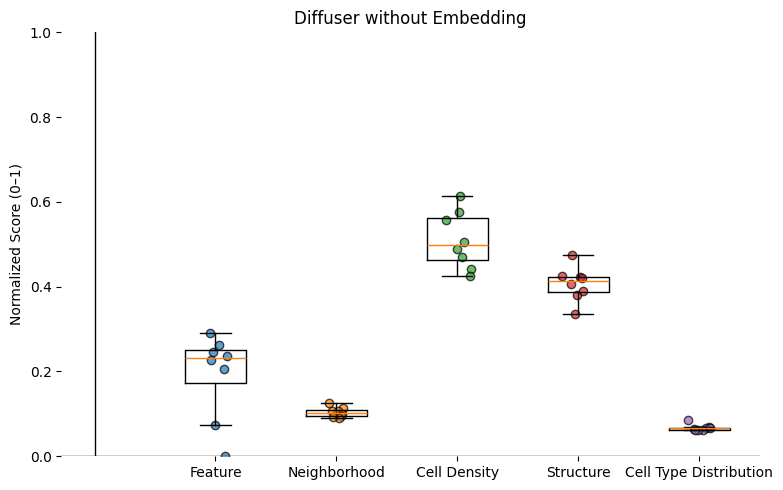

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 指标名
metrics = [
    'Feature',
    'Neighborhood',
    'Cell Density',
    'Structure',
    'Cell Type Distribution'
]

# Diffuser without embedding 的第二列数据（你提供的）
scores = [
    [0.24523133039474487, 0.11485617999501152, 0.5569571968127953, 0.4230661988258362, 0.0684901942398999],
    [0.0, 0.12473558775516126, 0.48819119661782084, 0.4195888042449951, 0.06658826359747688],
    [0.22650837898254395, 0.10737949017793094, 0.6143843754814025, 0.47408366203308105, 0.06314175204109956],
    [0.2918142080307007, 0.09967003061468548, 0.4699066927000215, 0.37965476512908936, 0.06536221102555201],
    [0.07357263565063477, 0.09538326678995164, 0.5760875030572519, 0.389779269695282, 0.06634095024534242],
    [0.23681962490081787, 0.10592536784791334, 0.4408009547996388, 0.3348332643508911, 0.06169236031044472],
    [0.20646142959594727, 0.09006518963123214, 0.5062339021920935, 0.4057045578956604, 0.06201807222348905],
    [0.2634601593017578, 0.09286088348287759, 0.42488726795631415, 0.42511796951293945, 0.08593387264952707]
]

# 转置为每列是一个指标的分数
data = list(zip(*scores))  # list of 5 lists, 每个 metric 一列


# 创建箱线图
plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=metrics, showfliers=False)

# 添加散点
for i, metric_vals in enumerate(data, start=1):
    x = np.random.normal(loc=i, scale=0.06, size=len(metric_vals))
    plt.scatter(x, metric_vals, edgecolor='black', alpha=0.7)

# 美化风格，模仿原始代码
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

plt.ylabel('Normalized Score (0–1)')
plt.ylim(0, 1)
plt.title('Diffuser without Embedding')
plt.grid(False)
plt.tight_layout()
plt.savefig("diffuser_without_embedding_boxplot.png")
plt.show()
